In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/AI/1CWK100/')

In [ ]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# Basic report structure

Please use the report structure set out in this notebook as your starting point. Once you are up and running then you are free to adjust it, but try to stick to the following basic approach: i) divide your investigation up into smaller code cells; ii) have text cells above each code cell briefly describing what is happening in the code, along with any relevant findings it produces.

Relatively quickly, you should be able to reuse some code from the labs to prepare the assignment dataset and evaluate at least one model with a basic holdout recipe. This would get you a pass. Ask for help if you're struggling, and read the later sections of this template once you're ready to start aiming for higher marks. Good luck!

# Overall Approach and Justification for the Pneumonia Dataset

## **Models Used**

When evaluating the pneumonia dataset, the traditional machine learning models I will use are Decision Trees, Random Forest, K-Nearest Neighbours, Naive Bayes, Support Vector Machines (SVM) and Logistic Regression (specifically stochastic gradient descent (SGD) with loss set to 'log_loss', effectively making it the same as traditional Logistic Regression). Each of these models have their own strengths and weaknesses, as well as suitability for the case of detecting pneumonia.

Decision Trees are intuitive and easy to interpret, which makes them a reasonable starter for understanding feature importance. Despite this, they are prone to overfitting without proper adjustment (such as careful hyperparameter tuning), particularly with complex datasets, unless regularisation techniques, such as limiting the tree depth, are applied. Random Forest acts as an upgrade from Decision Trees by training multiple Decision Trees in what is called an 'ensemble', where multiple instances of the same model are trained on different subsets of the data, and then the predictions are averaged out, reducing overfitting by considering the overall abilities of each different tree. Though, it can be computationally expensive to train each tree individually, depending on how deep they are and how many trees there actually are. K-Nearest Neighbours is an easy-to-implement method that relies on how close different data points are to each other. It can yield decent performance with structured datasets, but is also computationally expensive with large datasets.

Naive Bayes is a probabilistic classifier that assumes feature independence, and it can often be efficient and perform well on certain datasets, provided these are cleaned and processed reasonably. Support Vector Machines are very powerful when working with large datasets and are effective for binary classification tasks such as detecting pneumonia. However, they are computationally intensive and require wise hyperparameter tuning to recover the best performance. Logistic Regression (specifically SGD) is a model that performs well given that there is a linear relationship between the features and target variable, by optimising a linear decision threshold using stochastic gradient descent. Using log-loss as the loss function for Logistic Regression through this classifier makes it an efficient choice for large-scale datasets, and therefore practical for this investigation scenario. SGD also comes with advantages over normal Logistic Regression, as it allows for more efficient training on large datasets, updating model parameters incrementally and processing the data in single samples. This makes SGD more efficient as well as less memory and computational resource-intensive, by acting as an optimised version of traditional Logistic Regression.

Artificial Neural Networks (ANNs) are another traditional machine learning model, although not the most suitable for this instance of training using tabular data. This is because ANNs are better-suited to tasks where raw X-ray image analysis is required. Deep learning models such as Convolutional Neural Networks (CNNs) are the most proficient at automatically identifying intricate patterns and features, reducing the need for manual intervention and data collection. As a result, this particular model would be more suitable for the "Extension Exercise" section of this notebook, where X-ray images are analysed in depth using image recognition neural network models to justify a claim.

## **Key Metrics for Evaluation**

In my analysis, the primary metric to evaluate model during cross-validation is ROC AUC, which is an essential metric for detecting pneumonia, especially for imbalanced datasets. This metric measures a model's ability to classify between positive and negative classes, so the greater this value, the better the model is at differentiating between sensitivity (true positive rate) and specificity (true negative rate) across all classification thresholds. Therefore, this metric combines other useful metrics (mainly sensitivity and specificity) and varies the minimum threshold on the positive class, ensuring it provides useful insights into how discriminative the model is in the face of imbalanced data, and an essential metric for the case of avoiding misclassifications. Furthermore, using ROC-AUC as the main metric for cross-validation ensures that the model used for final testing is able to properly distinguish between the positive and negative classes, which makes sure that the final results from the testing stage can be considered realistic, unbiased and fair, as the model is less likely to favour the the class with more instances over the class with less instances. As a result, the grid searches will have this metric set as the 'scoring' argument's value, so that the best hyperparameter combinations found from grid searching prioritise ROC-AUC.

Once the cross-validation process for each model has been completed, the model with the highest ROC-AUC score will then be used for a final evaluation on the unseen test set, as the model with the highest score is more likely to yield better results that are more promising in terms of generalisation. During the final evaluation on the test set, additional metrics I will calculate will be recall, precision, F1 score and confusion matrix, which will, altogether, provide a conclusion on the model's ability to balance false positives (pneumonia cases that are actually false but predicted as true) and false negatives (pneumonia cases that are actually true but predicted as false), while ultimately minimising false negatives.

Specifically, recall and F1 score should be higher than precision for an optimal model in terms of pneumonia detection. This is because recall (true positive rate) measures the proportion of actual positive cases (true positives) that were correctly identified by the model. A high recall means the model can effectively capture the positive class. F1 score is another key metric that provides a harmonic mean of percision and recall, emphasising the importance of both. In the context of pneumonia detection, the F1 score is especially relevant as it accounts for the trade-off between false positives and false negatives, which is crucial in medical diagnosis for minimising patient risk (avoiding false negatives) and unnecessarily following up on non-pneumonia cases (avoiding false positives).

Precision calculates the proportion of correctly identified positive cases out of all cases predicted as positive by the model, with a higher precision meaning that the model has fewer false positives. Although minimising false positives is another crucial step in ensuring optimal model performance, this does not have as severe an impact as minimising false negatives. This is because false negatives mean pneumonia cases that are actually positive are predicted as negative by the model, so they are overlooked, making this very fatal s not handled properly. On the other hand, a higher number of false positives mean that there are unnecessary follow-up treatments by the clinical staff, which is not as dangerous as missing a pneumonia case, so minimising false negatives (maximising recall) takes large precedence over minimising false positives (maximising precision).

Another source I will use to evaluate the results will be the confusion matrix, which provides a detailed breakdown of true positives, true negatives, false positives and false negatives. This matrix allows for deeper insights into how well the model is able to distinguish between pneumonia and non-pneumonia cases correctly, as well as showcasing where errors occur during the process. As a result, I will comment on the model's performance in terms of the confusion matrix by checking to see if there are more true positives and true negatives (correctly identified cases) than false positives and false negatives (incorrectly identified cases), which overall indicates decent performance. Despite this, false positives still play a crucial role in maximising recall (ensuring there are as little false negatives as possible). By allowing for some false positives, the model can ensure that fewer actual pneumonia cases are missed, which can be fatal in a medical context where overlooking actual pneumonia cases can lead to serious consequences. Therefore, while aiming to minimise false positives, it is essential to strike a balance between trues and falses to ensure the best possible model performance, as well as patient safety, and reduce unnecesary follow-ups.

Throughout this notebook, ROC AUC will be the central metric to focus on, as this will provide a more realistic insight into how the model is able to distinguish between true and false, and positive and negative classes, on the unseen holdout test set. As a result, the grid searches will have this metric set as the 'scoring' argument's value, so that the best hyperparameter combinations found from grid searching prioritise ROC AUC, making sure the final evaluation is considered meaningful and robust based on the imbalanced dataset.

On the other hand, accuracy is a misleading metric for this investigation, as it can be negatively influenced by class imbalance, giving an unfair and biased evaluation of the model's performance in datasets with unequal class distributions. This is because a model with a high accuracy might become biased towards the majority class, and as a result, fail to identify instances of the minority class. This is notably an issue in situatins involving crucial detection of the minority class, including detecting pneumonia, as this would otherwise undermine the model's reliability and give false results. Therefore, the earlier-mentioned metrics are more suitable for this investigation, as they provide a clearer and more comprehensive analysis of the model's ability to address class imbalance effectively. Therefore, accuracy will not be calculated during the investigation, reinforcing the reliability of the results.

## **Ensembles**

In addition to the base models listed above, I will incorporate ensemble methods to enhance performance and achieve more robust and reliable predictions. Ensemble techniques combine the predictions of multiple different models, or multiple instances of the same model trained in different ways, to reduce variance and bias and improve generalisation to unseen data, which are crucial in the context of medical data analysis and pneumonia detection, where predicting the probability of pneumonia and non-pneumonia cases correctly, takes precendence over randomly assuming the outcome of a certain case based on previously seen data.

Notably, the ensembles I will focus on will be Bagging (Bootstrap Aggregating) and Voting. Bagging (Bootstrap Aggregating) allows us to build effective models by training multiple instance of the same model on a different subset of the data generated through bootstrapping (random sampling with replacement), and then averaging predictions. This helps to reduce overfitting and improve stability, especially for Decision Trees, which are vulnerable to overfitting. By minimising the noise or variance that certain models might pick up during training, Bagging can enhance stability by taking advantage of the combined strengths of all the model instances.

Voting is a classifier that combines predictions from multiple models, even if they're entirely different (the more independent they are of each other (such as decision trees and k-nearest neighbours, the better), as arguments for their estimators. This flexibility makes them extremely useful for leveraging the strengths of various models to produce more robust predictions.

For my investigation, I will use a Bagging classifier with the best-performing model, allowing this to be trained on random subsets of the data, and a Voting classifier to combine the predictions of the top two best (and entirely distinct) models, improving the chances of maximising performance by taking into account diverse models. In utilising these ensembles, I aim to enhance the base models' ability to distinguish between true and false instances of pneumonia and improve overall predictive performance. This will enable me to provide reliable results that make use of the various models' strengths and minimise false negatives as much as possible.

## **Optimisation Strategies**

To optimise model performance during cross-validation, I will use grid search as a method for tuning hyperparameters for each model. This approach iterates through every hyperparameter value in a defined grid, ensuring optimal configurations for each model. By doing this, I can maximise individual model performance, tailoring the hyperparameters to fit with the specific requirements of the pneumonia dataset (maximising ROC AUC). This process will also be valuable when combined with cross-validation, as it ensures that the chosen hyperparameters generalise well across the different data folds, reducing the risk of overfitting and enhancing robustness.

Another strategy I will use is stratified k-fold cross-validation for each model, to generate predictions and evaluate performance across multiple splits of the data. This method ensures that the evaluation is reliable, as well as considering any imbalances in the dataset, as the class distribution is kept the same within each fold. This will also mitigate potential biases that may arise as a result of a single train-test split and obtain an thorough implication of how each model behaves under different hyperparameter tunings and ensembles. At the very end of the investigation, I will identify the best-performing model based on the evaluation metrics, with a keen focus on ROC AUC (which is vital in pneumonia detection with imbalanced data). This model will then be applied to a final test set, which has been held out until this stage. The final evaluation will provide a solid indication of how effective the model generalises to unseen data, ultimately providing a score of suitability for its task of pneumonia detection.

# Dataset preparation

## **Cleaning the Data**

This code cleans the raw pneumonia dataset, ensuring it is ready for splitting. The .csv file is first loaded into the session, with the target feature then being defined as 'Pneumonia' (as this contains the yes/no results from the observations), and then various operations take place to rectify the mistakes it contains. Throughout the cleaning process, debugging statements are included at various stages, to check that the operations carried out work as expected (such as correcting typos actually correcting the typos in the dataset itself).

Specifically, the first operation is to ensure that the dataset does not contain any missing values, which is a common feature of raw data. Observations (rows) with missing values are dropped, which is acceptable in this case as we are unable to decide whether it is safe to impute missing values with the average for the same feature value column, which could cause data leakage. The next step is dropping duplicate observations, which is another common raw data feature, and this ensures that a repeated observation does not accidentally skew the data by drawing extra attention to the results from this observation.

Next, typos are rectified in the target feature, where there is one target feature value as 'np', which is then corrected to 'no', ensuring binary classification between yes and no. The next step is converting the target feature values into a binary number format (where 1 corresponds to 'yes', and 0 corresponds to 'no'), as this makes it easier for the models to identify the positive and negative classes, but still making sure that the target feature is of a categorical data type, to avoid confusion with the predictive features (which are all usually of a numerical format).

After this, a correlation heatmap is plotted to visualise how the different features are affected by each other, and the 'Patient_ID' feature is removed, as this does not provide any useful information for the models to make predictions with (since it doesn't form useful patterns with the target feature), and also because each of the squares for the 'Patient_ID' on the correlation matrix are 0 or close to 0, indicating no direct relationship with the other features. A summary of the value distributions for each feature, as well as a boxplot to visualise these distributions, is shown, and it is found that 'Max_Consolidation_Width' and 'Max_Consolidation_Height' have a min value of -10000. Because we know these values cannot be negative (as they represent physical dimensions (in millimetres or centimetres) of the area of consolidation), these are removed by deleting the associated observations, and a second boxplot is displayed to confirm that this has removed all negative values, which it has.

Finally, a bar chart is visualised to show the distribution of the target feature's values, and it is found that class 1 ('yes') has more values than class 0 ('no'). This represents imbalanced data, which is handled by stratified sampling during the splitting stage (further down). The dataset shape, including the number of observation rows and feature columns, is shown, with 581 observations and 11 features, excluding 'Patient_ID' (whose deletion is also confirmed when printing out the final observations structure, as this column now no longer exists and is no longer shown).

Raw observations information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                584 non-null    int64  
 1   Patient_Age               584 non-null    int64  
 2   Male                      584 non-null    float64
 3   Xray_Brightness           584 non-null    float64
 4   Xray_Contrast             584 non-null    float64
 5   Silhouette_Sign           584 non-null    int64  
 6   Max_Consolidation_Width   584 non-null    int64  
 7   Max_Consolidation_Height  584 non-null    int64  
 8   Cavity_Presence           584 non-null    float64
 9   Fluid_Level               584 non-null    float64
 10  Air_Bronchograms          584 non-null    float64
 11  Pneumonia                 584 non-null    object 
dtypes: float64(6), int64(5), object(1)
memory usage: 54.9+ KB
None

Observations information 

<ipython-input-4-a2a5e73d3e48>:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observations[target_feature] = observations[target_feature].replace({'no': 0, 'yes': 1})  # Convert 'no' to 0 and 'yes' to 1
<ipython-input-4-a2a5e73d3e48>:46: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  observations[target_feature] = observations[target_feature].replace({'no': 0, 'yes': 1})  # Convert 'no' to 0 and 'yes' to 1


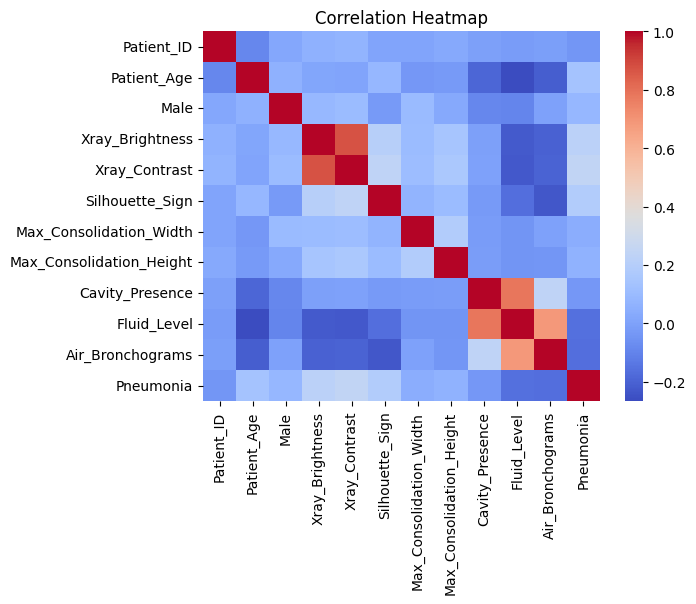


Observations now:

   Patient_Age  Male  Xray_Brightness  Xray_Contrast  Silhouette_Sign  \
0           60   1.0              0.7            0.2              174   
1           18   1.0              1.3            0.7              316   
2           43   1.0              1.3            0.6              155   
3           38   1.0              1.0            0.3              216   
4           23   1.0              1.1            0.5              191   

   Max_Consolidation_Width  Max_Consolidation_Height  Cavity_Presence  \
0                       32                        14              7.8   
1                       10                        21              6.0   
2                       15                        20              8.0   
3                       21                        24              7.3   
4                       37                        41              7.7   

   Fluid_Level  Air_Bronchograms Pneumonia  
0          4.2               1.1         0  
1          2

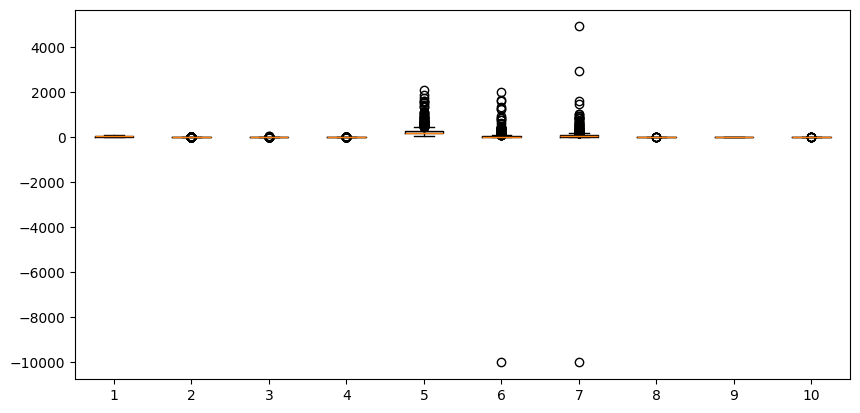

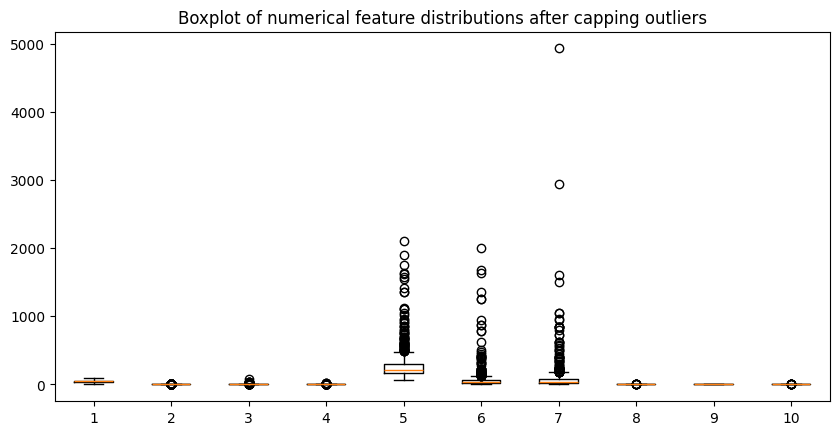


Summary of statistics of value distributions in the numerical columns after removing negative values:

       Patient_Age        Male  Xray_Brightness  Xray_Contrast  \
count   581.000000  581.000000       581.000000     581.000000   
mean     44.734940    0.757315         3.307229       1.490361   
std      16.215636    0.429076         6.218550       2.812394   
min       4.000000    0.000000         0.400000       0.100000   
25%      33.000000    1.000000         0.800000       0.200000   
50%      45.000000    1.000000         1.000000       0.300000   
75%      58.000000    1.000000         2.600000       1.300000   
max      90.000000    1.000000        75.000000      19.700000   

       Silhouette_Sign  Max_Consolidation_Width  Max_Consolidation_Height  \
count       581.000000               581.000000                581.000000   
mean        290.855422                80.910499                110.153184   
std         243.306773               182.903985                289.386

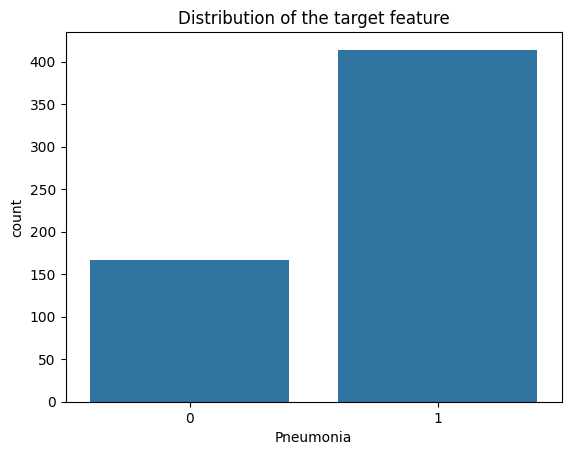


The first few rows of the cleaned dataset:

   Patient_Age  Male  Xray_Brightness  Xray_Contrast  Silhouette_Sign  \
0           60   1.0              0.7            0.2              174   
1           18   1.0              1.3            0.7              316   
2           43   1.0              1.3            0.6              155   
3           38   1.0              1.0            0.3              216   
4           23   1.0              1.1            0.5              191   

   Max_Consolidation_Width  Max_Consolidation_Height  Cavity_Presence  \
0                       32                        14              7.8   
1                       10                        21              6.0   
2                       15                        20              8.0   
3                       21                        24              7.3   
4                       37                        41              7.7   

   Fluid_Level  Air_Bronchograms Pneumonia  
0          4.2               1.1

In [ ]:
# Importing the packages we use
import pandas as pd # For data analysis and manipulation
import numpy as np # For mathematical operations
import seaborn as sns # For statistical data visualisation, mainly the correlation heatmap here
import matplotlib.pyplot as plt # The main library for plotting

# Load the dataset into the session
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Checking initial information about the observations
print("Raw observations information:\n")
print(observations.info())

# Remove observations with missing values
observations = observations.dropna()

# Check the observations after dropping missing values
print("\nObservations information after dropping missing values:\n")
print(observations.info())

# Remove duplicate observations
observations = observations.drop_duplicates()

# Check the observations after dropping duplicates
print("\nObservations information after dropping duplicates:\n")
print(observations.info())

# Check the unique values of the categorical target feature
print("\nUnique values of the categorical feature:\n")
print(observations[target_feature].value_counts())

# Fix typos in the target feature (specifically replacing 'np' with 'no')
observations[target_feature] = observations[target_feature].replace('np', 'no')

# Check the unique values of the categorical target feature after fixing typos
print("\nUnique values of the categorical feature after fixing typos:\n")
print(observations[target_feature].value_counts())

# Ensure that the target feature is of a categorical data type, following conventions for machine learning
observations[target_feature] = observations[target_feature].astype('category')

# Convert target variable to a numerical binary format
observations[target_feature] = observations[target_feature].replace({'no': 0, 'yes': 1})  # Convert 'no' to 0 and 'yes' to 1

# Check the data types of each feature, ensuring the target feature (Pneumonia) is now of 'category' type
print(f"\nData types for each feature:\n")
print(observations.dtypes)

# Create a correlation matrix
corr_matrix = observations.corr()

# Plot the correlation matrix as a heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Drop Patient_ID, as it's not relevant, based on the correlation heatmap, as well as standard conventions for machine learning
observations = observations.drop(columns='Patient_ID')

# And now see what the observations look like, making sure Patient_ID is no longer there
print("\nObservations now:\n")
print(observations.head())

# Check the statistics of the value distributions in each column
print("\nSummary of statistics of value distributions in the numerical columns:\n")
print(observations.describe())

# Define examples as all the predictive features
examples = observations.drop(columns=target_feature)

# Set the boxplot figure size
plt.figure(figsize=(10, 4.8))

# Create the boxplot
plt.boxplot(examples)
plt.show()

# Remove observations with obvious outliers (usually negative values)
# Both 'Max_Consolidation_Width' and 'Max_Consolidation_Height' have a min value of -10000, which cannot be possible
observations = observations[observations['Max_Consolidation_Width'] >= 0]
observations = observations[observations['Max_Consolidation_Height'] >= 0]

# Select numeric columns
numeric_columns = observations.select_dtypes(include=[np.number]).columns

# Display a boxplot of the numerical feature distributions now
plt.figure(figsize=(10, 4.8)) # Set a figure size for the boxplot
plt.boxplot(observations[numeric_columns]) # Plot the boxplot with only the numeric columns
plt.title('Boxplot of numerical feature distributions after capping outliers') # Add a title
plt.show() # Visualise the boxplot

# And check that there are no obvious outliers in any of the columns now
print("\nSummary of statistics of value distributions in the numerical columns after removing negative values:\n")
print(observations.describe())

# Visualise the distribution of the target feature
sns.countplot(x=target_feature, data=observations)
plt.title('Distribution of the target feature')
plt.show()

# Display the first few rows of the cleaned dataset
print("\nThe first few rows of the cleaned dataset:\n")
print(observations.head())

# Check the final shapes of the dataset, which tells us how many observations and features there are in the cleaned dataset
print(f"\nThe cleaned dataset contains {observations.shape[0]} observations and {observations.shape[1]} features.")






## **Splitting the Data**

This code then splits the data into 60% for training and 40% for testing to ensure there is sufficient testing data that can learn from the training data, without increasing the risk of overfitting to the training data, shuffling the data to ensure randomness, but making sure each split allocates the same data for training and testing through a random state of 99. Firstly, a custom function is defined to logarithmically transform all outliers (values greater than 1.5, and less than 1.5, times the interquartile range), reducing the effect of these values while not completely deleting them, as the outliers might still be important parts of the medical data. Each column in the dataset undergoes logarithmic transformation on its outliers, and this is then wrapped in a function transformer as it is an arbitrary callable, which can then be used in the preprocessing pipelines for each model (further down).

The examples (observations of all the predictive features (not the target feature)) and labels (all the observations of the target feature) are then defined before being separated into training examples and labels, and testing examples and labels (which will be used at the very end for a final model evaluation only). The split also includes stratified sampling to ensure that the example-label pairs are divided up based on their associated labels, and then randomly sampling from pairs with the relevant labels based on the label fractions seen in the original data. This makes sure that the imbalanced data produces a marginally equal ratio of labels for both the positive and negative classes in the training and testing datasets, so that the proportion of each class is maintained in the splits. A final check is implemented to ensure that the ratios for the entire dataset, as well as the divided training and testing sets, are all similar, which they are (0.403 to 0.404, only a 0.001 difference).

In [ ]:
# Importing the packages we use
import pandas as pd # For data analysis and manipulation
import numpy as np # For mathematical operations
from sklearn.model_selection import train_test_split # For splitting the data into training and testing sets
from sklearn.preprocessing import FunctionTransformer # For returning the results of user-defined functions, especially useful for taking logarithms of values and doing custom scaling, as done during the investigation

# Define a function for outlier handling (log transformation)
# This helps to reduce the skewness of the data while ensuring the outliers are not removed, as these may still be essential parts of the data that provide useful (but unusual) information
# This function will be used during the preprocessing pipelines for each model, as applying this to the entire data could introduce leakage
def log_transform_outliers(X):
    X = pd.DataFrame(X)  # Ensure compatibility with pandas
    for col in X.columns: # For each feature column
        Q1 = X[col].quantile(0.25) # Calculate the lower quartile
        Q3 = X[col].quantile(0.75) # Calculate the upper quartile
        IQR = Q3 - Q1 # Calculate the interquartile range
        lower_bound = Q1 - 1.5 * IQR # Calculate the lower bound
        upper_bound = Q3 + 1.5 * IQR # Calculate the upper bound
        outliers = (X[col] < lower_bound) | (X[col] > upper_bound) # Define the outliers based on values less than the lower bound or greater than the upper bound
        X.loc[outliers, col] = np.log1p(X.loc[outliers, col]) # Apply logarithmic transformation on these outliers
    return X.values # And return the new and transformed values

# Define the pipeline for the log transformer (which will be used in each model's preprocessing pipeline)
log_transformer = FunctionTransformer(log_transform_outliers, validate=False)

# Define examples and labels
examples = observations.drop(target_feature, axis=1) # Set the examples to all the features apart from the target feature

# Use the target feature ('Pneumonia') as the label for binary classification
labels = observations[target_feature]

# Split into training (60%) and testing (40%) data with shuffling and stratified sampling
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples, # Use the examples
    labels, # Use the labels
    test_size=0.4, # Allocate 40% of the data for testing
    random_state=99, # Set a random state to ensure reproducibility
    shuffle=True, # Shuffle the data to ensure randomness, reducing human error
    stratify=labels # Apply stratified sampling with the complete set of labels again, making sure each class receives an equal number of labels
)

# Get the label counts for the entire dataset
observation_counts = observations[target_feature].value_counts()

# Get unique label counts in the training and testing datasets
train_unique, train_counts = np.unique(train_labels, return_counts=True)
test_unique, test_counts = np.unique(test_labels, return_counts=True)

# Print ratios (no to yes) for the entire dataset, as well as the newly created training and testing datasets
print(f"The ratio in the observations is: {observation_counts[0] / observation_counts[1]:.3f}")
print(f"The ratio in the training data is: {train_counts[0] / train_counts[1]:.3f}")
print(f"The ratio in the testing data is: {test_counts[0] / test_counts[1]:.3f}")

The ratio in the observations is: 0.403
The ratio in the training data is: 0.403
The ratio in the testing data is: 0.404


# Model 1 evaluation - Decision Tree

Decision trees form the foundation of supervised learning. When the model is fit on training data, a tree structure is generated and stored inside the model's parameters. The tree structure contains conditional questions at each node level that splits the data, based on the result of a Boolean condition (such as "is x less than y?"), into increasingly smaller subsets with less diversity between training labels.

When predictions are made on the test data, the individual feature values in each example are used to navigate through the tree to a leaf (end) node. A predicted label is generated based on the training data associated with the node by finding the most common label (a pneumonia or non-pneumonia case).

The most useful hyperparameter for decision trees is `min_samples_split`, which controls the minimum number of samples required to split an internal node into two children nodes. The greater this value, the lower the risk of overfitting, as the tree will not be allowed to grow too deep, but the harder it can be for the model to learn patterns from the training data, as the tree will not become deep enough. Therefore, finding a balance is essential for the most optimal performance.

This code evaluates a decision tree model by using a grid search to find the best hyperparameter combination to maximise ROC AUC. A pipeline is created, which includes the preprocessing steps, followed by the model (a random state of 99 is given to ensure reproducibility of results (the results are the same every time the code is run)). The pipeline contains a `SimpleImputer` function to replace any missing values in a column with the mean of values in the same column, the custom-defined `log_transformer` function to transform outliers and reduce skewness in the data distribution without deleting these outliers, as these may still provide important and useful, albeit unusual, information about the patients. `StandardScalar` is also applied after this to ensure the predictive feature ranges are similar across all features, helping the model to learn patterns more easily and clearly without becoming distorted. Finally, the model is fitted into the end of the pipeline, after all data preprocessing has taken place, and the final pipeline is used throughout the investigation, guaranteeing no data leakage, and making sure data preprocessing happens before fitting the model onto the cleaned and preprocessed data.

This pipeline ensures that each fold during cross validation contains consistent preprocessing, which is crucial to avoid data leakage, as each fold will not influence the predictions made by the next folds. Stratified k-fold cross-validation is set up, with 10 folds being generated, as this allocates sufficient validation data for effective model evaluation, without overfitting on the training data, as well as avoiding sampling purely at random, which is a result of human error. This also ensures that each fold is of an equal size, with a separate evaluation being carried out on each individual fold, while training the model on the other k-1 folds, ensuring that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time).

The best `min_samples_split` value that maximises ROC AUC, found from the grid search is 65, and a graph is plotted to visualise how the mean ROC AUC score differs in relation to different `min_samples_split` values. Grid searching is very useful for this investigation, as it reduces the need for multiple nested loops (if more hyperparameters were being tuned), and makes the whole tuning process easier for us by allowing us to specify a grid of hyperparameter values (where the nested combinations lie), as well as setting a scoring metric of interest, which it aims to maximise. We fit the pipeline and associated hyperparameter grid into the `GridSearchCV` function, along with ROC AUC as the `scoring` argument and our `StratifiedKFold` function to handle the stratified k-fold cross-validation in each fold during the search for the best hyperparameter combination.

Once the hyperparameter tuning is completed, the model with the best combination (highest ROC AUC) is extracted via the `best_estimator_` attribute of the grid search, and this best model is then used for cross-validation in each of the stratified folds, with a focus on the ROC AUC scores. The mean ROC AUC score (the total score across all folds divided by the number of folds) is returned to give a solid insight into how well the model performs on the validation data. Here, a mean score of 0.7374 indicates that the model is somewhat proficient at discriminating between the positive and negative classes (pneumonia and non-pneumonia cases. Moreover, it is performing better than random guessing, as the mean score is above 0.5, so the model is able to generalise decently to unseen data.

Finally, the best decision tree itself is visualised, giving us an in-depth representation of the decisions it makes at each node level, as well as the final model parameters. In doing this, we can see that the tree has a depth of 7, and the root node answers the question of "is x-ray brightness less than or equal to 0.078?" (as Xray_Brightness is the 3rd (second index in the array) predictive feature, using a zero-based index). The `plot_tree` function uses the convention of 'Yes' (or True) to lead to the left child node, and 'No' (or False) to lead to the right child node. Other arguments in each node are `gini` (the diversity score for the labels associated with the node (0.41 for the root node, indicating mid-diversity)), `samples` (the total number of training example/label pairs associated with the node (all 348 of the example/label pairs in the training data, for the root node)) and `value` (the number of times each unique label occurs in the training laels associated with the node (100 for negative (class 0) and 248 for positive (class 1) in the root node)). This process is repeated until a leaf node is reached, where label predictions are generated, based on the most common label in the data associated with the node.

Model 1: Decision Tree...



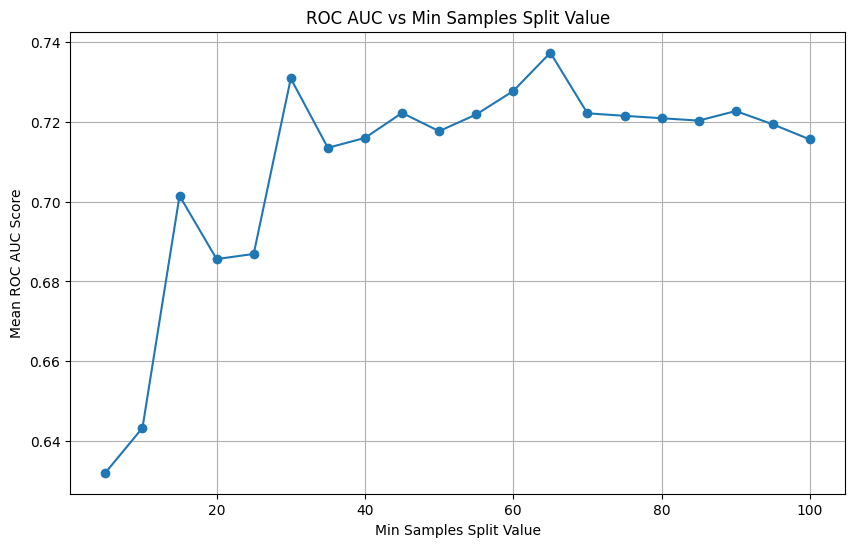


The best hyperparameters found to maximise ROC AUC are: {'model__min_samples_split': 65}

Mean ROC-AUC Score from Cross-Validation: 0.7374


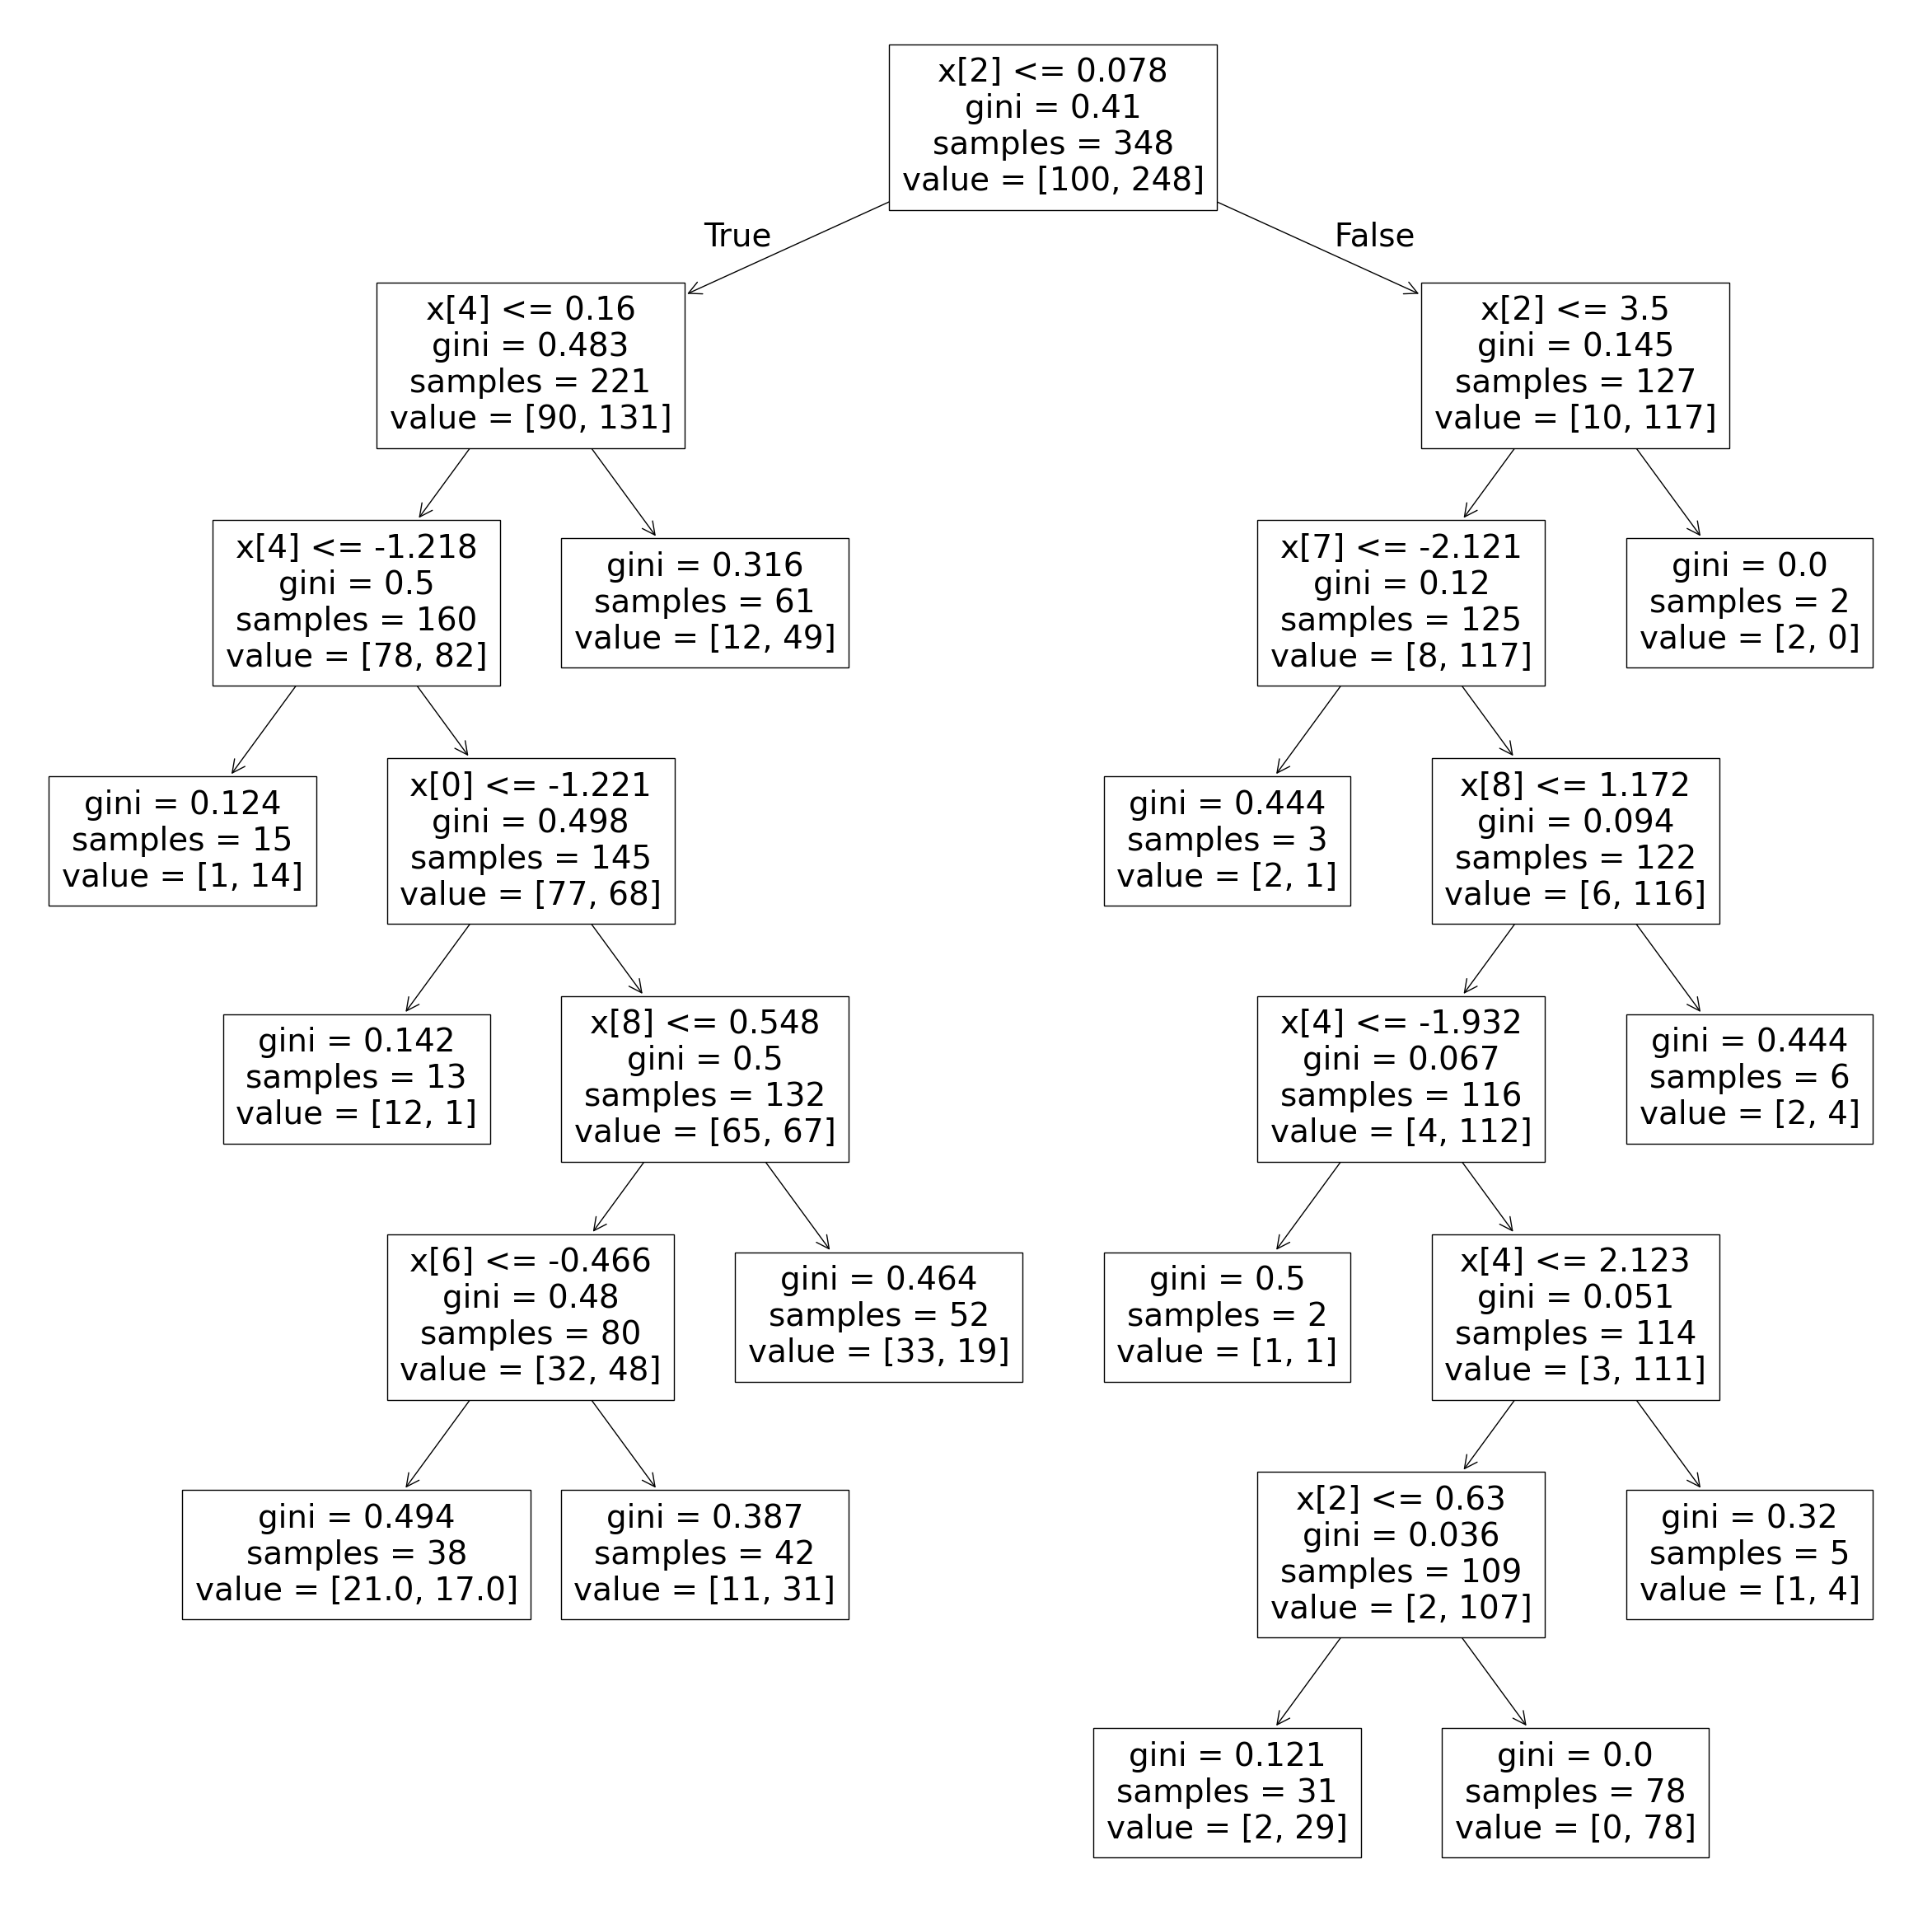

In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.tree import DecisionTreeClassifier, plot_tree # The decision tree model skeleton, as well as the function to plot and visualise the tree
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 1: Decision Tree...\n")

# Create a decision tree classifier model object, with a random_state of 99 to ensure reproducibility
dt_model = DecisionTreeClassifier(random_state=99)

# Create a pipeline combining our model with our preprocessing steps
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewness
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', dt_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'model__min_samples_split': list(range(5, 101, 5))  # Tunes the minimum number of samples required to split an internal node
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_dt = GridSearchCV(
    estimator=dt_pipeline,  # The model (decision tree) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_dt.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_dt.cv_results_

# Get the parameter values and corresponding ROC AUC scores
min_samples_split_values = results['param_model__min_samples_split'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the min_samples_split values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(min_samples_split_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs Min Samples Split Value') # Add a title
plt.xlabel('Min Samples Split Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_dt.best_params_}\n")

# Get the best model from grid search
best_dt_model = grid_search_dt.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_dt_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")

# Plot the tree itself to visualise it
plt.figure(figsize=(30, 30)) # Set the tree figure size
plot_tree(best_dt_model.named_steps['model']) # Get the 'model' parameter of the best decision tree (as this is a pipeline that contains the preprocessing steps as well)
plt.show() # Visualise the tree


# Model 2 evaluation - Random Forest

Random forest acts as an upgraded version of basic (as well as single) decision trees, by creating a 'forest' (sometimes, more technically, also called an 'ensemble') of different trees, and training each of them in different ways. When a random forest model is fit on the training data, each decision tree model randomly samples the training data with replacement (the same example/label pair can be sampled multiple times), and each decision tree model randomly samples features without replacement (the same example/label pair cannot be sampled multiple times) every time it looks for a new split.

When predictions are made on the test data, each decision tree is used to generate probability scores for each label, based on the fractions of training labels in the relevant leaf nodes. These scores are averaged using soft voting in order to find an overall predicted label. The full soft voting result can be returned if label probabilities are needed.

The most useful hyperparameter for the random forest model is `n_estimators`, which controls the number of trees that are in the ensemble itself. The higher this value, the lower the risk of overfitting. However, the greater the number of trees to train, the more computationally expensive it can be, but the better the results.

This code evaluates a random forest model with a random state of 99 to also ensure reproducibility and the same results every time the code is run. In the same way as with decision trees, a preprocessing pipeline is created with the steps and the model itself, which is then used during the cross-validation to ensure no data leakage. Stratified k-fold cross-validation is carried out with 10 splits, to ensure each fold has the same size, ensuring consistency and reducing bias, while maintaining sufficient validation data for effective model evaluation.

During hyperparameter tuning, the best `n_estimators` value found to maximise ROC AUC score was 95, and again, a graph is plotted to visualise the mean ROC AUC scores over each `n_estimators` value within the defined range. When finding the best hyperparameter combination, grid search is used again with the model pipeline and the hyperparameter grid, along with ROC AUC as the `scoring` argument to maximise this. The model that contains the best combination is extracted and then used during the cross-validation recipe, generasting a score for each fold, and then calculating the mea score across all folds, which turns out to be 0.7600. This indicates that random forest performed better than decision tree on its own, as random forest trains multiple trees on different subsets of the training data, allowing for averaging the predictions across each tree and improving generalisation by not overfitting to a single portion of the data.

Model 2: Random Forest...



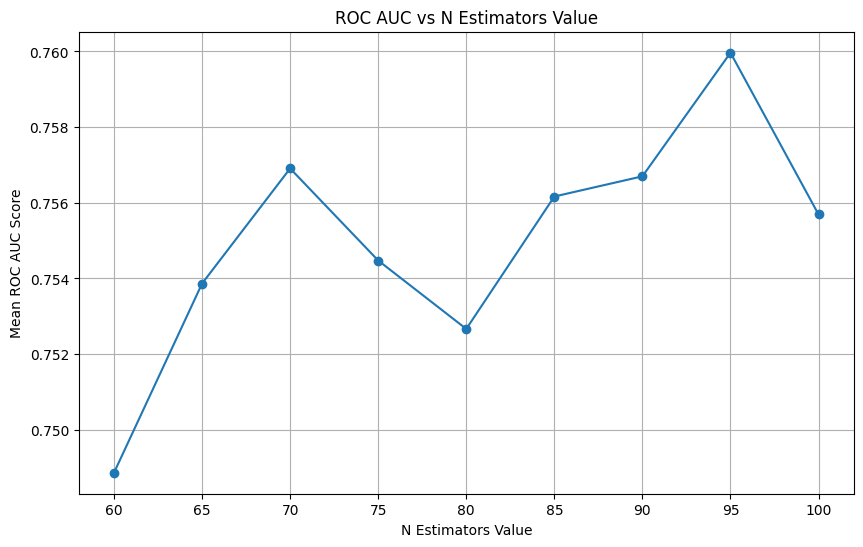


The best hyperparameters found to maximise ROC AUC are: {'model__n_estimators': 95}

Mean ROC-AUC Score from Cross-Validation: 0.7600


In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.ensemble import RandomForestClassifier # The random forest model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 2: Random Forest...\n")

# Create a random forest classifier model object, with a random_state of 99 to ensure reproducibility
rf_model = RandomForestClassifier(random_state=99)

# Create a pipeline combining our model with our preprocessing steps
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewness
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', rf_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'model__n_estimators': list(range(60, 101, 5))  # Tunes the number of decision trees in the forest to train
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,  # The model (random forest) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_rf.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_rf.cv_results_

# Get the parameter values and corresponding ROC AUC scores
n_estimators_values = results['param_model__n_estimators'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the n_estimators values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(n_estimators_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs N Estimators Value') # Add a title
plt.xlabel('N Estimators Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_rf.best_params_}\n")

# Get the best model from grid search
best_rf_model = grid_search_rf.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_rf_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")



# Model 3 evaluation - K-Nearest Neighbours

K-Nearest Neighbours works by finding the closest data points (neighbours) to a given input based on a distance metric and then using the labels to make predictions. When the model is fit on training data, the parameters are set to store a copy of the examples and labels passed in.

When predictions are made on the testing data, each individual testing example is compared to all the training examples, and a similarity score is calculated based on how closely the features of the test example match those of each training example. The more similar the two values are, the smaller the score. The training examples and labels are then sorted based on the similarity score, meaning we see the most similar examples and their associated labels at the top. A prediction is generated by looking for the most common label within the window.

The main hyperparameter for K-Nearest Neighours is `n_neighbors` (determines the number of nearest neighbours to consider for making predictions). The smaller this values, the more precise the explanation of the training data, but the greater the risk of overfitting, as the model will rely on fewer data points for making predictions, and may become overly specialised to these. This can influence the prediction process, because the model becomes susceptible to noise and outliers in the training data, leading to poor generalisation when benchmarked against the testing data

This code evaluates a k-nearest neighbours model, using the same preprocessing pipeline, and fitting this into the grid search mechanism to find the best hyperparameters. Stratified k-fold cross-validation is used to ensure that each fold is of the same size as the others during grid search, as well as cross-validation on the best model. It was found that the `n_neighbors` value that yielded the highest ROC AUC score was 80, which is associated with a mean ROC AUC score of 0.7412, and a graph is also plotted to show variations in this metric as per the `n_neighbors` value.

The best model is given to us via the grid search's `best_estimator_` attribute, which contaisn the preprocessing pipeline, along with the best hyperparameters, and this best model is then passed into the `cross_val_score` function to generate scores for each of the 10 folds, calculating the mean average as a final indication of model performance. The score of 0.7412 is better than the decision tree, but worse than the random forest model. However, the value of `n_neighbors` is decently high, meaning that the risk of overfitting is still unlikely.

Model 3: K-Nearest Neighbours...



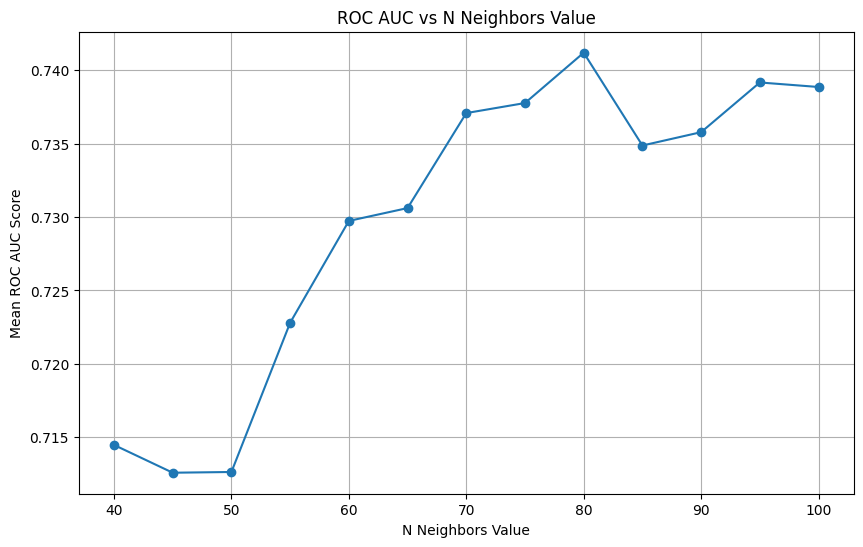


The best hyperparameters found to maximise ROC AUC are: {'model__n_neighbors': 80}

Mean ROC-AUC Score from Cross-Validation: 0.7412


In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.neighbors import KNeighborsClassifier # The k-nearest neighbours model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 3: K-Nearest Neighbours...\n")

# Create a k-nearest neighbours classifier model object
knn_model = KNeighborsClassifier()

# Create a pipeline combining our model with our preprocessing steps
knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewness
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', knn_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'model__n_neighbors': list(range(40, 101, 5))  # Tunes the number of nearest neighbours
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_knn = GridSearchCV(
    estimator=knn_pipeline,  # The model (k-nearest neighbours) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_knn.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_knn.cv_results_

# Get the parameter values and corresponding ROC AUC scores
n_neighbors_values = results['param_model__n_neighbors'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the n_neighbors values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(n_neighbors_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs N Neighbors Value') # Add a title
plt.xlabel('N Neighbors Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_knn.best_params_}\n")

# Get the best model from grid search
best_knn_model = grid_search_knn.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_knn_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")


# Model 4 evaluation - Naive Bayes

The Naive Bayes classifier works by assuming that all features are independenrt given the label input, which simplifies the computation of probabilities. The model predicts the label for a given input by finding the label with the highest probability, based on the observed feature values.

During training, the model is fitted on the training data, which calculates the probability of each feature value given each label using training data. These probabilities are represented by a mathematical function, such as a normal distribution, for each pair of features and labels, and these are stored in the model parameters.

When predictions are made on the testing dataset, Bayes' theorem is used to calculate the probability of each label for a given test example. This involves multiplying the probabilities of all feature values for each label and selecting the label with the highest probability.

Naive Bayes has few hyperparameters, so is very simple, and makes there very little to tune. This makes it efficient and straightforward to implement, but also limits flexibility in making predictions.

This code evaluates a naive bayes model by embedding this in a preprocessing pipeline, along with the data preprocessing steps in the logical order (imputation, then logarithmic transformation, then scaling, before applying the model to the process). This ensures no data leakage, leading to a fair, realistic and unbiased model evaluation. Grid searching is not done here, as naive bayes does not use hyperparameters to tune performance, so the untuned pipeline is passed into `cross_val_score` to compute the cross-validation scores for each of the 10 folds. The mean ROC AUC found was 0.7587, which is the best score so far, indicating that the naive bayes model is likely to yield a solid performance on the final evaluation (if the other upcoming models don't perform better). However, the lack of hyperparameters might make this score misleading, as the way of optimising the model is out of our control.

In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.naive_bayes import GaussianNB # The naive bayes model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)

# A print statement so we know which model we are evaluating
print("Model 4: Naive Bayes...\n")

# Create a naive bayes classifier model object
nb_model = GaussianNB()

# Create a pipeline combining our model with our preprocessing steps
nb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewness
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', nb_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(nb_pipeline, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")


Model 4: Naive Bayes...

Mean ROC-AUC Score from Cross-Validation: 0.7587


# Model 5 evaluation - Support Vector Machine


SVM is a classifier that finds the optimal hyperplane (decision boundary) that separates different data points of different class in the best way. This is done by focusing on the points which are the hardest to classify (support vectors) and trying to create the largest possible margin between classes.

When the model is fit on training data, SVM considers all data points, but focuses on those closest to the decision boundary (support vectors). It optimises the parameters to maximise the margin between this boundary and the support vectors, ensuring the best possible separation of classes.

When predictions are made on the testing dataset, the SVM model determines which side of the hyperplane to go on. The class is assigned based on this side of the boundary, and also often, the distance from the boundary is used to calculate these probabilities.

SVM makes use of the essential hyperparameter `gamma`, which is the kernel coefficient for 'rbf' kernel. The higher this value, the more local the range of data used for training points, and therefore, the greater the risk of overly specialised data, and overfitting.

This code evaluates a support vector machine model with a random state of 99 to ensure the results are the same every time the code is run, probability set to True to make sure the predicted probabilities can be used during final testing, and class weight set to balanced, which is also important for support vector machines, as this adjusts the class weights inversely proportial to class frequencies in the input data, making sure no class is under-represented or over-represented. The model is embeeded in a preprocessing pipeline, to ensure data preprocessing takes place before passing the model into the grid search, as well as the cross-validation mechanisms. `StratifiedKFold` is used to split into 10 folds, each of which keeps the percentage of samples for each class the same, to ensure consistency and lack of bias during the process.

During hyperparameter tuning, the best `gamma` value found to maximise ROC AUC score was 0.09, with an associated mean score of 0.7645, and a graph to visualise how this mean value changes based on the `gamma` value. Based on this score, the support vector machine is the best performing model by far, which indicates a solid performance on the validation data, making this model very likely to yield the best possible performance on the final test data, potentially if combined with another top-performing model in a voting ensemble (see below).

Model 5: Support Vector Machine...



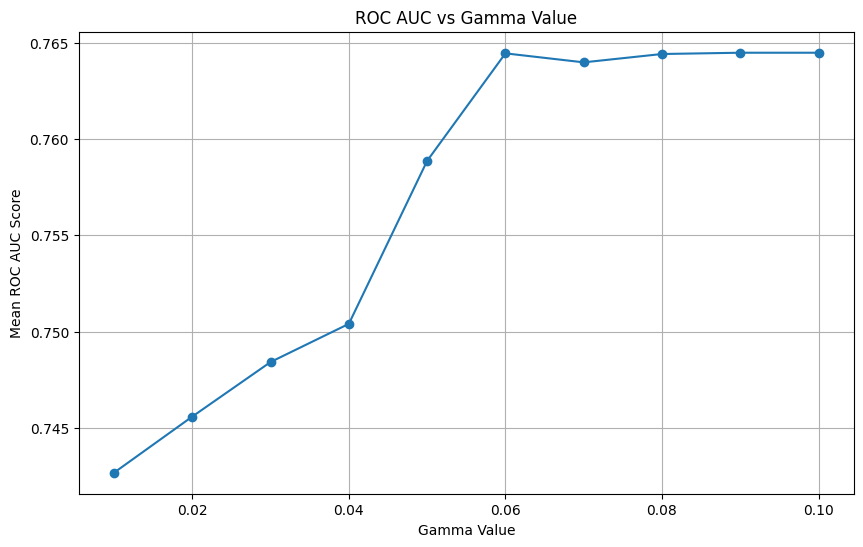


The best hyperparameters found to maximise ROC AUC are: {'model__gamma': 0.09}

Mean ROC-AUC Score from Cross-Validation: 0.7645


In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.svm import SVC # The support vector machine model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 5: Support Vector Machine...\n")

# Create a support vector machine classifier model object, with a random_state of 99 to ensure reproducibility
# Probability is set to True so it calculates probability estimates (in case this model turns out to be the best, and we want to calculate predicted probabilities when evaluating it on the unseen test set)
# The class weight is also set to balanced, so that both classes are equally represented during cross-validation, reducing the favouring over a particular class over the other
svm_model = SVC(probability=True, class_weight='balanced', random_state=99)

# Create a pipeline combining our model with our preprocessing steps
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewnessz
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', svm_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'model__gamma': [x / 100 for x in range(1, 11)]  # Tunes the kernel coefficient
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,  # The model (support vector machine) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_svm.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_svm.cv_results_

# Get the parameter values and corresponding ROC AUC scores
gamma_values = results['param_model__gamma'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the gamma values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(gamma_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs Gamma Value') # Add a title
plt.xlabel('Gamma Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_svm.best_params_}\n")

# Get the best model from grid search
best_svm_model = grid_search_svm.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_svm_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")


# Model 6 evaluation - Logistic Regression

Logistic Regression (SGD specifically) works by fitting a decision boundary, which is usually a straight line, or place for higher-dimensional data, that separates data points of different classes. The model estimates probabilities for each class using the logistic function and assigns the class with the highest probability.

When the model is fit on the training data using SGD, it considers a small subset of data points, or a single data point, at each iteration. The parameters of the decision boundary are updated iteratively by minimising a loss function, such as cross-entropy, to find the line or hyperplane that best separates the classes. These optimised parameters are then stored in the model.

During predictions on testing data, the model uses the decision boundary to classify each test example based on which side of the boundary it falls. If probabilities are required, the model calculates them using the logistic function and assigns the label with the highest probability.

The most useful hyperparameter for SGDClassifier is `max_iter` (The maximum number of passes over the training data (also known as 'epochs')). A higher `max_iter` value can eventually lead to a static performance that no longer improves (called convergence). Therefore, a higher value can allow the model to learn sufficient data to make better predictions and explanations.

This code evaluates a logistic regression model with a random state of 99 to ensure reprodicbility of the results, and a loss of 'log_loss' to make it implement the logistic regression classifier's prediction mechanism. A pipeline, which contains the preorocessing steps (imputation, log transformation and scaling) and the model itself, is set up for the analysis. The grid search includes the model pipeline, a hyperparameter grid (which contains a range of `max_iter` values), the stratified k-fold cross-validation object of 10 splits, and the main metric for focus as the ROC AUC score, ensuring this is maximised for the best model. A graph is plotted to visualise the mean ROC AUC scores and the different `max_iter` values' relationship.

Based on the findings, the best `max_iter` value was 1000 epochs, but this gave a mean ROC AUC score of 0.6665, meaning that this model performed the worst so far. However, as logistic regression optimises the log-likelihood function through an iterative algorithm (gradient descent), the optimal performance has already been found, regardless of this hyperparameter's value.

Model 6: Logistic Regression...



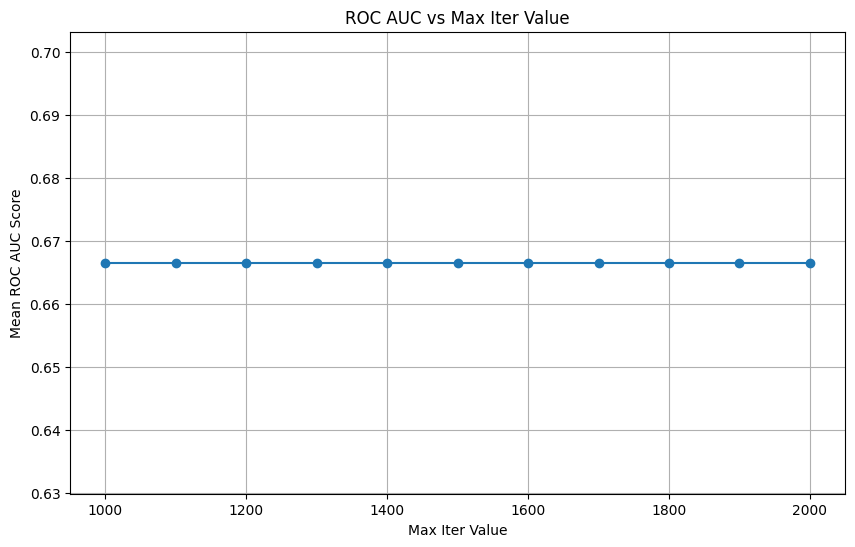


The best hyperparameters found to maximise ROC AUC are: {'model__max_iter': 1000}

Mean ROC-AUC Score from Cross-Validation: 0.6665


In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.pipeline import Pipeline # For creating a pipeline to combine preprocessing steps with the model itself, mitigating data leakage
from sklearn.linear_model import SGDClassifier # The logistic regression model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
from sklearn.preprocessing import StandardScaler # For standardising the data, which makes sure that each predictive feature has a similar range to the others, making it easier for the model to find patterns in the data
from sklearn.impute import SimpleImputer # For imputing missing values within the data (usually the mean of all values in the same column)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 6: Logistic Regression...\n")

# Create a logistic regression classifier model object, with a random_state of 99 to ensure reproducibility, and log_loss set to loss to make it use logistic regression
logreg_model = SGDClassifier(loss='log_loss', random_state=99)

# Create a pipeline combining our model with our preprocessing steps
logreg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # First, impute missing values with the mean of values in the respective feature columns
    ('log transformer', log_transformer), # Then log transform outliers to reduce skewness
    ('scaler', StandardScaler()), # Apply the standard scalar to standardise features by removing the mean (making this 0) and dividing by the respective standard deviation (making this 1)
    ('model', logreg_model) # Pass the model into the pipeline for training
])

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'model__max_iter': list(range(1000, 2100, 100))  # Tunes the maximum number of search steps to take looking for the best model parameters
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_logreg = GridSearchCV(
    estimator=logreg_pipeline,  # The model (logistic regression) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_logreg.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_logreg.cv_results_

# Get the parameter values and corresponding ROC AUC scores
max_iter_values = results['param_model__max_iter'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the max_iter values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(max_iter_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs Max Iter Value') # Add a title
plt.xlabel('Max Iter Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_logreg.best_params_}\n")

# Get the best model from grid search
best_logreg_model = grid_search_logreg.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_logreg_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")



# Model 7 evaluation - Ensembles

Based on the best-performing models, these ensemble classifiers are now used to assess how model performance can be improved if distinct models are intergrated into one, or if a single model is trained on different subsets of the data. The two main ensembles for assessment are bagging and voting, as these allow the combination of more than one model to provide a solid indication of performance during cross-validation, on unseen data. Technically speaking, random forest is an ensemble in its own right, but this is only tailored for decision trees, so other models are more likely to be included in specially made ensemble classifiers.

## **Bagging**

Bagging works by training each instance of the same model on different subsets of the training data (bootstrap aggregating). By default, models will draw the same number of samples as the number example-label pairs, but because the samepling is done with replacement (the same example-label pair can be sampled multiple times), each model only sees, usually, about 64% of the training data, with each model seeing a different 64% each time, providing a decent level of independence between models.

(**Note:** A preprocessing pipeline is not explicitly defined in the below code cell. This is because the bagging classifier has the best support vector machine model as the base estimator, which already contains a preprocessing pipeline, as well as the best hyperparameters found during the evaluation. Therefore, including another preprocessing pipeline here would be redundant, and likely cause errors, as the preprocessing would take place twice)

The support vector machine model performed the best, as it achieved a mean ROC-AUC cross-validation score of 0.7645. As a result, the best support vector machine model (which includes the preprocessing pipeline and the best model hyperparameters) will be used as the base estimator for a bagging classifier.

Here, a bagging classifier is defined with the best support vector machine model pipeline, and a random state of 99 to ensure the results of the analysis are the same every time the code is run. A key hyperparameter, `n_estimators`, is tuned, which dictates the number of support vector machine models in the ensemble itself to train. The higher this value, the lower the risk of overfitting, but the more computationally expensive it can be to train each support vector machine instance. Stratified k-fold cross-validation is used during the grid search for the best hyperparameter value, which works out at 5, to ensure that each fold is of an equal size, ensuring consistency during cross-validation.

A graph is plotted to show the differences in the mean ROC AUC score against different `n_estimators` values. The best bagging model is recovered, which gives an optimal mean ROC AUC score of 0.7518 during cross-validation. However, this mean score is lower than the single best support vector machine model on its own, so this ensemble is not considered the best for the final testing.

Model 7a: Bagging Ensemble...



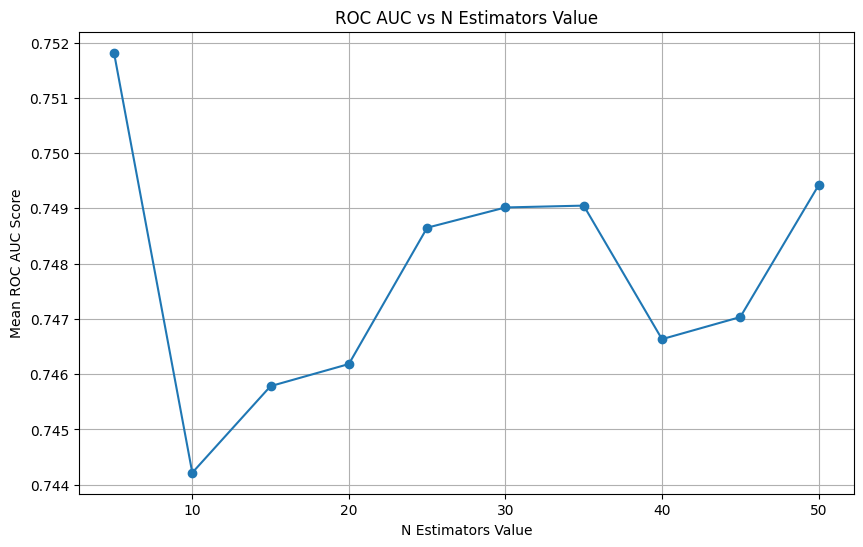


The best hyperparameters found to maximise ROC AUC are: {'n_estimators': 5}

Mean ROC-AUC Score from Cross-Validation: 0.7518


In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.ensemble import BaggingClassifier # The bagging ensemble model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    GridSearchCV, # For iterating over all hyperparameter combinations to find the best set
    cross_val_score # For doing the cross-validation itself
)
import matplotlib.pyplot as plt # For plotting visualisations, specifically graphs for hyperparameter investigations, including the ROC-AUC scores against different hyperparameter values here

# A print statement so we know which model we are evaluating
print("Model 7a: Bagging Ensemble...\n")

# Create a bagging ensemble classifier model object, with a random_state of 99 to ensure reproducibility, and the best support vector machine model (which contains the preprocessing pipeline and the best hyperparameters)
bagging_model = BaggingClassifier(best_svm_model, random_state=99)

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Hyperparameter grid for tuning
param_grid = {
    'n_estimators': list(range(5, 51, 5))  # Tunes the number of support vector machine models in the ensemble to train
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_bagging = GridSearchCV(
    estimator=bagging_model,  # The model (bagging ensemble) to optimise during hyperparameter tuning
    param_grid=param_grid,  # The grid of hyperparameters to search through
    scoring='roc_auc',  # Metric to optimise (maximise the Area Under the ROC Curve)
    cv=skf,  # Cross-validation strategy (Stratified K-Folds for preserving class proportions in each fold)
    n_jobs=-1,  # Use all available CPU cores for parallel computation
    refit=True  # Refit the model on the full training data with the best hyperparameters after the search
)

# Perform grid search on the training data to find best hyperparameters
grid_search_bagging.fit(train_examples, train_labels)

# Extract the results from GridSearchCV
results = grid_search_bagging.cv_results_

# Get the parameter values and corresponding ROC AUC scores
n_estimators_values = results['param_n_estimators'] # Get each of the hyperparameter values in the defined range
roc_auc_scores = results['mean_test_score'] # And each value's corresponding mean ROC AUC score

# Plotting the n_estimators values against ROC AUC scores
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(n_estimators_values, roc_auc_scores, marker='o', linestyle='-') # Plot the two variables against each other
plt.title('ROC AUC vs N Estimators Value') # Add a title
plt.xlabel('N Estimators Value') # Set the label for the x-axis
plt.ylabel('Mean ROC AUC Score') # Set the label for the y-axis
plt.grid(True) # Add a grid layout
plt.show() # Show the graph

# Print the best hyperparameters found from the grid search
print(f"\nThe best hyperparameters found to maximise ROC AUC are: {grid_search_bagging.best_params_}\n")

# Get the best model from grid search
best_bagging_model = grid_search_bagging.best_estimator_

# Compute ROC-AUC scores on the best model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(best_bagging_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# And print the mean score
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")


## **Voting**

Voting ensembles work by combining the predictions of multiple different models to improve overall performance. Recovering the best possible performance requires the models in the ensemble to be as independent as possible (so for example, a decision tree and random forest model would not work well together in a voting ensemble, as they both use trees for their underlying prediction mechanisms).

By using soft voting here, the `predict_proba()` method is called on each base estimator in the ensemble, and the label probability scores are averaged, with the label that has the highest resulting probability score being used as the ensemble's prediction. This soft voting strategy means a draw between the base estimators' predictions is much more unlikely, compared to hard voting, which only uses the most common label without averaging. Furthermore, setting voting to soft allows us to calculate probability scores, which can be useful when calculating the ROC AUC score on unseen test data and plotting a ROC-AUC curve to visualise the trade-offs between the true positive rate and false positive rate (see below).

(**Note:** A preprocessing pipeline is not explicitly defined in the below code cell, for the same reason as the bagging classifier (see above))

The two best-performing models are random forest and support vector machine (which are both very independent models, making these suitable for being used in a voting ensemble to yield optimal performance). As a result, these two models are included in a voting classifier, using soft voting. The voting model is then passed into the `cross_val_score` function to calculate cross-validation scores for ROC AUC across each of the 10 folds, and the total of these is then averaged, giving a mean ROC AUC score of 0.7721. As the voting ensemble has the highest mean ROC AUC score out of all the other models (due to averaging the predictions of both best-performing models from the investigation), this model will be used for the final testing on the held-out and unseen test dataset (see below). Furthermore, the standard deviation across all folds is calculated (which comes to 0.0974), and this value will be used as a benchmark for whether the model is largely overfitting on the training/validation data, and therefore how well it generalises to unseen data. This can be concluded if the test set ROC AUC score is less than the mean ROC AUC cross-validation score minus the standard deviation.

In [ ]:
# Import the packages we need
import numpy as np # For mathematical operations (usually calculating the mean averages from cross-validation here)
from sklearn.ensemble import VotingClassifier # The voting ensemble model skeleton
from sklearn.model_selection import (
    StratifiedKFold, # For splitting the data into training/validation partitions with stratified sampling
    cross_val_score # For doing the cross-validation itself
)

# A print statement so we know which model we are evaluating
print("Model 7b: Voting Ensemble...\n")

# Create a voting ensemble classifier model object
voting_model = VotingClassifier(estimators=[
    ('svm', best_svm_model), # Define one of the estimators for the voting classifier as the best support vector machine model (which contains the preprocessing pipeline and best hyperparameters)
    ('rf', best_rf_model) # Define one of the estimators for the voting classifier as the best random forest model (which contains the preprocessing pipeline and best hyperparameters)
], voting='soft') # Use soft voting, which ensures that the model produces probability scores for each model in the ensemble, and the label with the highest resulting probability is used as the ensemble's prediction. This ensures a draw between the estimators is unlikely

# Set up a StratifiedKFold object to create 10 different folds, using stratified sampling
# This ensures that every one of the example/label pairs is used the same number of times in model training (k-1 times) and also in model evaluation (1 time)
skf = StratifiedKFold(n_splits=10)

# Compute ROC-AUC scores on the model for each of the 10 folds using cross-validation
roc_auc_scores = cross_val_score(voting_model, train_examples, train_labels, cv=skf, scoring='roc_auc')

# Get the mean ROC AUC score from the cross-validation
mean_roc_auc = np.mean(roc_auc_scores)

# Also get the standard deviation for the ROC AUC score, which will be used to assess overfitting
# This is only calculated for the voting model because this has the highest mean ROC AUC score, so will be used for the final evaluation on the unseen test dataset
std_roc_auc = np.std(roc_auc_scores)

# And print the mean and standard deviation scores
print(f"Mean ROC-AUC Score from Cross-Validation: {mean_roc_auc:.4f}")
print(f"Standard Deviation ROC-AUC Score from Cross-Validation: {std_roc_auc:.4f}")


Model 7b: Voting Ensemble...

Mean ROC-AUC Score from Cross-Validation: 0.7721
Standard Deviation ROC-AUC Score from Cross-Validation: 0.0974


# Final Test

Based on the full investigation, the best-performing model is the voting classifier. As a result, this model will now be used to generate predictions on the testing data, which has been held out until this stage. The main metrics during this final evaluation are the confusion matrix, true positive rate, false positive rate, precision, recall, F1 score and ROC-AUC score and curve. Each of these metrics provides a useful piece of information to infer the model's overall usefulness and suitability for the task of detecting pneumonia using supervised learning.

This code fits the voting model to the training data, and then generates predictions on the test data. These predictions are then used to generate a confusion matrix, which provides a visual breakdown of the different classifications made by the model during the testing process, including how many of the predictions were correct and where the model went wrong. It calculates the true positives (the number of actual pneumonia cases correctly predicted as pneumonia), true negatives (the number of actual no pneumonia cases correctly predicted as no pneumonia), false positives (the number of actual no pneumonia cases incorrectly predicted as pneumonia) and false negatives (the number of actual pneumonia cases incorrectly predicted as no pneumonia), and displays these in the matrix itself.

After this, the confusion matrix is broken into each of these 4 sub-parts, and these are then used to calculate true positive rate, false positive rate, recall and precision, which are then used to calculate the F1 score. Precicted probabilities are calculated for the positive class, and the test ROC AUC score across all classification thresholds is generated, with an AUC function then being used to plot a ROC AUC curve to visualise the trade-off between the false positive rate and true positive rate.

Based on the results, the final voting model predicted 20 true negatives, 139 true positives, 47 false positives and 27 false negatives, along with a true positive rate of 0.8373, a false positive rate of 0.7015, a precision score of 0.7473, a recall score of 0.8373, an F1 score of 0.7898 and a ROC AUC score of 0.6963. The results indicate that the voting classifier performs reasonably well on the test data, although worse than how it performed during cross-validation. As the ROC-AUC score of the test data is lower than the cross-validation ROC-AUC score, this indicates moderate overfitting on the training and validation data. However, this is often expected, as the model was trained on an imbalanced dataset, so is more likely to consider the positive class more than the negative class. Additionally, despite log transforming the outliers during data cleaning, these might still be mildly extreme parts of the data that can cause overfitting on the training and validation data, although the impact of these is lower compared to if log transformation didn't take place. Despite this, the ROC AUC score is still decently high (above random guessing of 0.5), meaning that the final voting model is proficient at correctly distinguishing between both classes of pneumonia and no pneumonia, representing an impressive discriminative ability.

As both the recall and F1 score are greater than the precision score, this indicates that the model is able to classify many positives, although at the expense of false positives (which are not as critical in pneumonia detection as false negatives). The true positive rate is also greater than the false positive rate, which means that the model is able to correctly classify more true positives than false positives. Despite this, the false positive rate is reasonably high, which means that further tuning would be necessary to try and bring this down. Also, as the precision score is reasonably high, this indicates that the model correctly predicted many of the actual positive pneumonia cases (true positives), so is well-suited for the task of making fast and reliable pneumonia diagnoses, without patients having to wait for review by
clinical staff.

The confusion matrix shows that there are more false positives than false negatives, so this reinforces the safety net in applications where it is preferable to make errors on the side of caution by identifying more potential cases, even if some are incorrect (false positives). In pneumonia detection, this could mean flagging more patients for further testing rather than risking missing a serious condition, which would be the more advisable option, as overlooking a case can be fatal (false negatives).

Final results on unseen and held-out test dataset:



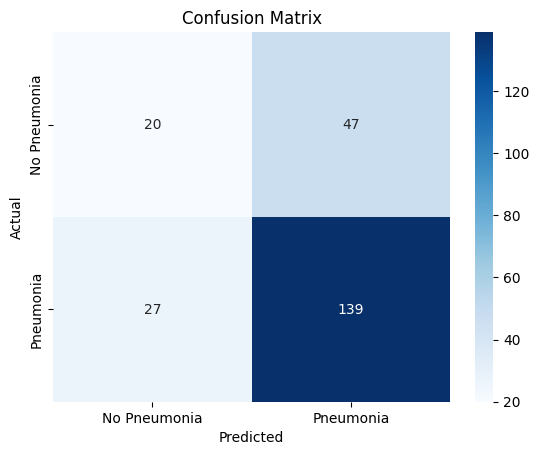

True Positive Rate (TPR): 0.8373
False Positive Rate (FPR): 0.7015
Precision Score: 0.7473
Recall Score: 0.8373
F1 Score: 0.7898
ROC AUC Score: 0.6963


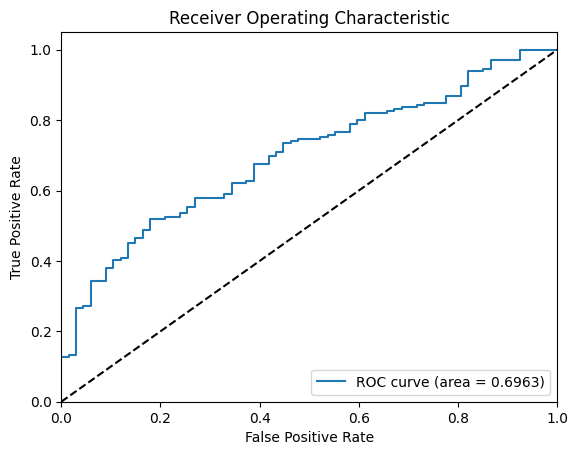

In [ ]:
# Import the packages we need
from sklearn.metrics import (
    confusion_matrix, # For working out the confusion matrix based on how the model classifies instances using the test data
    roc_curve, # For working out the ROC AUC curve, which visually displays the model's overall ability to differentiate between the positive and negative classes
    auc # For working out the ROC AUC score based on false positive rate and true positive rate
)
import seaborn as sns # For statistical data visualisation, mainly the confusion matrix here
import matplotlib.pyplot as plt # The main library for plotting

# A print statement so we know what we are evaluating
print("Final results on unseen and held-out test dataset:\n")

# Fit the voting model to the training data
voting_model.fit(train_examples, train_labels)

# Generate predictions on the test data using the voting model defined previously (as this was the model with the highest mean ROC AUC score during cross-validation)
predictions = voting_model.predict(test_examples)

# Plot the confusion matrix
cm = confusion_matrix(test_labels, predictions) # Calculate the confusion matrix based on the test labels (pneumonia and no pneumonia) and the model's predictions on the test examples
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Pneumonia', 'Pneumonia'], yticklabels=['No Pneumonia', 'Pneumonia']) # Plot the confusion matrix, with a coloured blue scale to show the value ranges, as well as the labels set more specifically to the task
plt.title('Confusion Matrix') # Add a title
plt.xlabel('Predicted') # Set the label for the x-axis
plt.ylabel('Actual') # Set the label for the y-axis
plt.show() # Show the matrix

# Divide the confusion matrix into its individual components
TP = cm[1, 1] # True Positives (the number of actual pneumonia cases correctly predicted as pneumonia)
FN = cm[1, 0] # False Negatives (the number of actual pneumonia cases incorrectly predicted as no pneumonia)
FP = cm[0, 1] # False Positives (the number of actual no pneumonia cases incorrectly predicted as pneumonia)
TN = cm[0, 0] # True Negatives (the number of actual no pneumonia cases correctly predicted as no pneumonia)

# Calculate and display the true positive rate
# This is the proportion of actual positives correctly identified by the model, or the ratio of correctly predicted positive observations to all the observations in the actual class
# This answers the question of "How many of the actual positives did we capture?"
TPR = TP / (TP + FN)
print(f"True Positive Rate (TPR): {TPR:.4f}")

# Calculate and display the false positive rate
# This is the proportion of actual negatives incorrectly classified as positives
# This answers the question of "Out of all the actual negative cases, what fraction were incorrectly classified as positive?"
FPR = FP / (FP + TN)
print(f"False Positive Rate (FPR): {FPR:.4f}")

# Calculate and display the model's precision on the test data
# This is the ratio of correctly predicted positive observations to the total predicted positives
# This answers the question of "How many of the positive predictions were actually correct?"
precision = TP / (TP + FP)
print(f"Precision Score: {precision:.4f}")

# Calculate and display the model's recall on the test data
# This is the same as the true positive rate
# This answers the question of "How many of the actual positives did we capture?"
recall = TP / (TP + FN)
print(f"Recall Score: {recall:.4f}")

# Calculate and display the model's F1 score on the test data
# This is the harmonic mean of recall and precision, which punishes extreme values more, so this metric will always be nearer to the smaller value of precision or recall
# This metric is crucial in classification tasks where both false positives and false negatives are expensive, especially in sensitive applications and imbalanced datasets, as it only increases when both precision and recall increase, making it a strict metric
f1_score = (2 * recall * precision) / (recall + precision)
print(f"F1 Score: {f1_score:.4f}")

# Generate predicted probabilities on the test data for the positive class
probabilities = voting_model.predict_proba(test_examples)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, probabilities) # Work out the true positive rate and false positive rate across all classification thresholds, using the predicted probabilities
roc_auc = auc(fpr, tpr) # Work out the test ROC AUC score
print(f"ROC AUC Score: {roc_auc:.4f}") # Printing this

# Plot the ROC curve
plt.figure() # Define the figure
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})') # Plot the true positive rate against the false positive rate, with a label including the test ROC AUC score for reference
plt.plot([0, 1], [0, 1], 'k--') # Use a dashed diagonal line
plt.xlim([0.0, 1.0]) # Set the limit for the x-axis
plt.ylim([0.0, 1.05]) # Set the limit for the y-axis (so we can visibly see where the curve is at the top right)
plt.xlabel('False Positive Rate') # Set the label for the x-axis
plt.ylabel('True Positive Rate') # Set the label for the y-axis
plt.title('Receiver Operating Characteristic') # Add a title
plt.legend(loc='lower right') # Make the label appear in the lower right of the curve
plt.show() # Visualise the curve


# Conclusion for the Pneumonia Dataset

This investigation considered the decision tree, random forest, k-nearest neighbours, naive bayes, support vector machine and logistic regression models, as well as bagging and voting ensemble models. It was found that the voting ensemble, with the best random forest and best support vector machine models as the base estimators, gave the strongest performance with a mean ROC AUC score of 0.7721.

When the voting model was evaluated on the unseen test dataset, the ROC AUC score (0.6963) was lower than the cross-validation ROC AUC score (0.7721), indicating overfitting. However, as the test score is within the range of the mean score minus the standard deviation (0.0974), this still indicates that the model generalises reasonably well to unseen data, and is able to discriminate well between the positive and negative classes, therefore making it a good fit for the job of detecting pneumonia cases using machine learning. This case of overfitting is usually expected in these cases where the dataset is imbalanced. However, the combination of proper and conventional data cleaning and splitting, hyperparameter tuning, stratified sampling, cross-validation, alternative metric calculations (unlike the default accuracy) and data processing at every stage of the evaluation process (via a pipeline) ultimately aims to mitigate data leakage at all costs, meaning that the final evaluation can be considered robust, meaningful and trustworthy.

The use of a voting ensemble, as opposed to simply passing in the single best-performing model (support vector machine) on its own, enhanced the model's predictions by leveraging the strengths of multiple algorithms to provide more stable predictions. By combining the outputs of both the random forest and support vector machine models, the ensemble mitigates the weaknesses of the individual models, improving overall reliability. Moreover, this ensemble reduces the risk of bias associated with any single algorithm's assumptions, making it especially well-suited for complex tasks such as detecting pneumonia from potentially noisy and imbalanced data. This reinforces the value of ensemble learning in medical applications, where precision and recall are crucial to ensure that both false positives and false negatives are limited. The final test revealed a high F1 score of 0.7898, which infers that the harmonic mean between the precision (0.7473) and recall (0.8373) reflects a strong balance between the model's ability to accurately identify true positives and minimise false negatives. This suggests that the model performs well in equally considering both precision and recall (but prioritising recall to minimise false negatives), making it suitable for the task at hand.

In conclusion, the voting model with the best random forest and support vector machine models is an effective and robust solution for the task of detecting pneumonia cases using supervised machine learning, without manual intervention by clinical staff. While there is still room for improvement through the use of more advanced techniques, the current model provides a solid and reliable foundation for further development and deployment in real-world practical applications.

# Extension Exercise

## **Introduction to the Problem**

Hospitals typically rely on medical staff to manually extract features (numerical measurements) from chest X-rays for diagnostic purposes. However, this process can be labour-intensive and requires expert knowledge. A colleague has suggested that directly classifying raw X-ray images using machine learning could potentially improve diagnostic performance while reducing the amount of manual work needed to be done by hospital staff. This analysis examines and evaluates the nature, feasibility, benefits, and potential drawbacks of this approach.

## **Analysis of the Proposed Claims**

### **"We can classify the raw X-ray images directly"**

This is valid claim, as CNNs are a reasonable fit for medical image analysis. They are proficient at identifying spatial patterns and can accept raw X-ray images without the need for manual feature engineering (Litjens et al., 2017). CheXNet, which was trained on the NIH dataset, validated that CNNs can detect pneumonia, as well as other conditions, at a very similar level to radiologists (Rajpurkar et al., 2017). However, ensuring the most robust performance is based on the assumption that there are large and diverse datasets that consider variations in patient data and high-quality images (Esteva et al., 2019).

Furthermore, manual extraction of measurements from X-ray images by hospital staff is labour-intensive and vulnerable to human error, which can lead to inconsistent and sub-optimal performance. A review showcases that while traditional feature extraction techniques are used, these often lack the capturing of complex and intricate patterns that are inherent in medical images, resulting in limited diagnostic accuracy (Litjens et al., 2017). Developing AI systems to replicate manual measurement extraction might continue existing flaws. A study comparing various handcrafted features for medical image classification found that these methods are often insufficient for the complexities of medical imaging, suggesting that direct analysis of raw images could be more effective (Shen et al., 2017).

CNNs have demonstrated major success in medical imaging by learning hierarchical feature representations directly from raw pixels. An in-depth review of deep learning in medical imaging highlights the effectiveness of CNNs in various diagnostoic tasks, including X-ray image classification (Esteva et al., 2019). Vision Transformers (ViTs) are another type of deep learning model that analyse images through attention mechanisms, being able to identify global relationships across images. Although their applications in medical imaging is emerging, they are very likely to continue capturing complex patterns in raw images. A recent study discusses the potential of ViTs in medical image analysis, indicating their suitability for tasks requiring modelling of long-range dependencies (Dosovitskiy et al., 2021).

Considering the big picture, deep learning classifiers ultimately aim to provide improved performance as opposed to manually-extracted features, as the intricacies of images is something that humans alone are unable to do accurately. A study on deep learning techniques for medical image classification indicates much better performance of CNNs over traditional models (Shen et al., 2017). This also allows clinicians to focus on higher-level tasks, as models can process large datasets efficiently, which is essential for modern healthcare. In the past, deep learning has taken medical image classification by storm, automating complex tasks and improving efficiency and scalability (Litjens et al., 2017).

### **"It should be possible to get improved performance"**

This claim is backed up by evidence from models including CheXNet and similar studies. This model achieved high sensitivity and specificity on tasks involving pneumonia detection, highlighting a significant advancement in traditional methods that involved manually extracting features and data results (Rajpurkar et al., 2017). Additionally, studies that have used NIH and similar large datasets have proved that CNNs can perform at the same level as, or sometimes better than, human clinicians in terms of accurately identifying conditions correctly, helping to enhance recall and potentially reduce false negatives (Rajpurkar et al., 2018; Irvin et al., 2019).

Studies in medical imaging frequently report that models trained directly on raw X-ray data tend to surpass traditional models that rely on manually-extracted features. For example, CNNs fine-tuned on X-ray datasets, such as CheXpert, have shown improvements in tasks such as pneumonia detection and fracture identification (Irvin et al., 2019). Review papers highlight that advanced models like ViTs and hybrid approaches can outperform traditional supervised learning methods by taking advantage of larger datasets and pre-training models on classification tasks (Zhou et al., 2016). Broader surveys on deep learning in medical imaging suggest that automated feature learning from raw data leads to higher diagnostic accuracy. For example, a review of CNN applications in medical imaging demonstrates their ability to do better than traditional techniques across various datasets (Litjens et al., 2017).

NIH ChestX-ray14 is a high-quality, annotated dataset that has allowed researchers to train and evaluate models effectively (Wang et al., 2017). This dataset provides a diverse and large-scale foundation to benchmark model performance. Semi-supervised and self-supervised learning aim to go beyond pure supervised learning by leveraging unlabelled data to nehance feature learning. For example, self-supervised pre-training methods, such as SimCLR, allow models to learn representations from unlabelled X-ray images before fine-tuning on labelled datasets, resulting in higher diagnostic performance (Chen et al., 2020). Models pre-trained on general vision datasets, such as ImageNet, are often fine-tuned on medical data, providing a strong foundation for classification tasks (Rajpurkar et al., 2017). This approach has been shown to boost performance when labelled data is inaccessible.

### **"Save on staff time"**

This claim is partially valid, because automated imaging models can streamline medical diagnostics by making manual intervention from staff unnecessary, which can help to save on time and resources (Shin et al., 2016). Despite this automation process, reliability and generalisation in CNNs still remain essential. If a model does not generalise to unseen data or different patient demographics or image qualities, staff will need to spend additional time examining the results (Maguolo and Nanni, 2021).

Training deep learning models such as CNNs from scratch can be very intensive and time-consuming, especially for extremely large datasets, as this often requires significant computational resources (Strubell, Ganesh and McCallum, 2019). Using pre-trained models through transfer learning can significantly reduce training time (Rajpurkar et al., 2018). For example, fine-tuning an EfficientNet model for X-ray image classification has proved to achieve high accuracy with reduced training time. Once trained, AI models can then process X-ray images rapidly, enabling quicker diagnostics and reducing the time staff spend on manual image analysis (Litjens et al., 2017).

High-quality, labelled datasets are essential for training AI models, however the initial collection and annotation of the data can be very time-consuming (Shen et al., 2017). The availability of public datasets, such as NIH Chest X-ray, and the use of data augmentation techniques, such as image rotation, can reduce the need for extensive new data collection (Wang et al., 2017). Another option is synthetic data, where the data collected is not real, but is rather used to create additional training examples, without the need for manual intervention or extensive collection time. This lessens the reliance on real-world datasets, potentially saving staff time (Frid-Adar et al., 2018). However, while synthetic data is valuable for training, validation still required real-world data to ensure clinical relevance (Litjens et al., 2017).

Deploying AI systems requires staff training to analyse the outputs of the models, as well as integrate the systems into the work. However, this training is usually a one-time occurence, and can lead to a lot of saved time in the future by streamlining workflows when the staff know what is required of them (Ghassemi, Oakden-Rayner and Beam, 2021). Likewise, AI models require ongoing maintenance, including updates and performance monitoring. This process usually includes time investment, but the long-term benefits include more efficient image processing and faster working, which ultimately enhances patient care without any delays (Litjens et al., 2017).

### **"Without any downsides"**

This claim is questionable, as it comes with limitations, and mitigation strategies are essential to try and reduce the impacts of these. Specifically, CNNs are often referred to as 'Black Boxes', meaning that their decision-making process is difficult for humans to understand. As a result, clinicians might not fully trust the outputs of such a model, reducing their trust and making situations as critical as pneumonia diagnoses, more urgent (Holzinger et al., 2019). Another concern of this claim is data privacy and security when handling raw X-ray images, therefore requiring strict measures to ensure the data can only be visible to trusted persons (Rieke et al., 2020). CNNs are also at risk of overfitting if trained on limited data. Likewise, changes in imaging techniques, equipment and patient data can worsen model performance in new clinical environments (Maguolo and Nanni, 2021). AI models are not entirely perfect and error-free. Misclassifications and false negatives could still lead to incorrect diagnoses, delayed treatments or other unexpected problems. For example, a model trained on biased data might under-perform for under-represented data, making healthcare worse (Ghassemi, Oakden-Rayner and Beam, 2021). Moreover, many advanced models, including CNNs and ViTs, are black boxes, so their underlying functionality is harder to interpret, and a lack of transparency can impact trust among clinicians and patients. As a result, techniques such as attention visualisations can provide insights into the parts of an X-ray that influenced the model's decisions.

Training AI on medical data without explicit patient or owner consent raises ethical concerns, as public datasets often contain anonymous data, but unexpected leaks or breaches of privacy can still occur (Halevy, Norvig and Pereira, 2009). Ethical considerations happen in life-threatening situations without appropriate human supervision (Ghassemi, Oakden-Rayner and Beam, 2021). Therefore, anonymisation and usage policies are crucial to ensure the data is used ethically and in accordance with legal guidelines. Furthermore, medical AI systems rely on sensitive patient data, so cybersecurity vulnerabilities can leak this information, causing harm to patients and hospitals (Kruse et al., 2016). Other techniques for mitigating this include encryption, regular auditing and obedience to data protection standards, such as GDPR. Automated machine learning can reduce the necessity for non-clinical staff who manually process or annotate X-ray images. However, this could also create new roles in AI system management and data curation. Retraining programmes can support staff in accustoming to new responsibilities. Training deep learning models, especially from scratch, can consume a vast amount of computational resources and power, contributing to a large carbon footprint, meaning that pre-trained models and augmentation is essential for reducing energy usage.

The UK Government's guidance on "Understanding Artificial Inteligence Ethics and Safety" provides a comprehensive foundation framework for the ethical and safe deployment of AI systems in the public sector (GOV.UK, 2019). These encompass a range of values, principles and techniques that drive moral conduct in the development and employment of AI systems. These models can cause individual and societal harm through misuse, lack of trust or unexpected negative consequences. AI projects may require design and development variations in governance structures to address unique ethical and safety challenges, so establishing a framework of ethical values and principles is crucial for responsible project delivery. This guide emphasises values such as integrity, responsibility, equality and confidentiality in AI system development. Implementing principles that uphold these values ensures ethical AI system deployment. Risk assessment is also vital for AI systems to prevent harm to others, as well as the public sector as a whole. Ongoing evaluation of AI models is essential to maintain safety and address emerging ethical concerns. This guide draws attention to the significance of integrating ethical considerations and safety measures during the AI project lifecycle. By following established ethical values and principles, as well as robust governance and risk management techniques, public sector organisations can release AI models that are both effective and aligned with societal expectations,

Another potential downside for classifying raw X-ray images directly comes from the integration of such models into clinical scenarios. This often causes an inconvenience in existing medical infrastructure, such as Picture Archiving and Communication Systems (PACS), as these might not have the capacity for existing AI-based tools, and introducing new interfaces could delay this process even further (Kotter and Ranschaert, 2020). A study noted that integrating AI tools into radiology practices requires significant upgrades or customisation, which can be very time-consuming and expensive (Wipro, 2023). Some clinicians may also be uncertain about adopting AI solutions, due to concerns about trust, interpretability and redundancy. The discrepancy between AI output and human decision-making results of clinicians can further complicate the argument for whether AI adoption is necessary or not. Furthermore, the transition phase, including testing, training and debugging AI systems, can cause delays in operations. This can add increased strain on already overwhelmed healthcare systems (Kotter and Ranschaert, 2020). To minimise the impact of this, clinicians should get involved in the design and deploymwent process of AI systems as early as possible, to ensure the tools meet practical needs and integrate seamlessly into workflows (Wipro, 2023). Thorough testing of the AI systems should also be carried out in advance, to ensure any bottlenecks or compatibility issues are addressed before full deployment, without causing extensive disruption (Kotter and Ranschaert, 2020).

Overfitting to training data is another common downside of classifying raw X-ray images. AI models, particularly deep learning systems, are prone to this if the training data is too specific, or lacks diversity, which can cause it memorise patterns from the training data in lieu of generalising to it, so performance on other datasets is sub-optimal (Heaton, 2017). For example, a model trained on X-rays from a single study might struggle to adapt to images from other studies that use different imaging equipment or protocols. Overfitted models may produce misleading outputs, such as falsely classifying normal images as having diseases (false positives) or missing cases (false negatives). This could lead to missed diagnoses or unnecessary follow-ups, undermining trust in the models. Strategies such as data augmentation and dropout regularisation can prevent overfitting. Also, training on multi-centre datasets can enhance the model's generalisation abilities across diverse clinical scenarios (Zech et al., 2018).

## **Overall Approach for the Image Classification Task**

### **Dataset and Models**

To analyse each of these claims in detail, I will use a Kagglehub dataset with pre-trained neural network models from HuggingFace, each of which has their own strengths and weaknesses for the task of classifying raw images. Specifically, the dataset I will use combines the NIH Chest X-ray Dataset (National Institutes of Health Chest X-Ray Dataset, 2017), which contains millions of labelled X-rays, providing a diverse set of samples, RSNA-STR Pneumonia Detection Challenge (Radiological Society of North America, 2018), which focuses on pneumonia detection, offering detailed annotations, and Paul Mooney's Chest X-Ray Images of pneumonia, which is a curated subset of these datasets (Mooney, 2017)(Santoso, 2024). I will only be using the one and final combined dataset for this task. This dataset is split into train, validation and test datasets beforehand, with the same number of classes ('NORMAL' and 'PNEUMONIA') in each dataset. The splitting into train, validation, and test datasets ensures proper evaluation of model generalisation, reducing data leakage and overfitting risks. With balanced classes in each split, performance metrics like accuracy, precision, recall, and F1 score will reflect the model's robustness for both NORMAL and PNEUMONIA cases.

The pre-trained models I will use include a CNN and a ViT. The ViT I will use is the Vision Transformer (base-sized model) by Google (Hugging Face, 2022), which was pre-trained on the ImageNet-21k dataset, providing rich feature representations, as well as handling global dependencies using attention mechanisms. However, this requires more computational resources than CNNs and is sensitive to image size and data augmentation strategies, such as random rotations and image flipping. The CNN I will use is ResNet-50 by Microsoft (Hugging Face, n.d.). This network is optimised for both performance and efficiency (speed and memory consumption), as well as strong generalisation performance, and customisation for larger-scale training. This model is well-suited for image processing tasks due to spatial feature extraction, but may struggle to identify global dependencies in large images, as well as hyperparameter tuning for the best possible performance.

### **Claim Evaluation During Coding**

"We can classify the raw X-ray images directly" will be evaluated by comparing performance metrics (accuracy, precision, recall and F1 score) with and without data augmentation techniques for each model. If the models achieve high metrics directly (without augmentation or manual preprocessing), compared to with augmentation, this supports the claim.

"It should be possible to get improved performance" will be evaluated by comparing the train, validation and test dataset performance across each model. As the ViT is said to be more advanced and capable than the CNN, if this model achieves higher performance compared to the other model, it indicates a valid claim.

"Save on staff time" will be evaluated by measuring the inference time per image using a batch of test images, and then comparing the training time and metrics for each model. If inference time is relatively low (less than 1 second) while maintaining high metrics, and if training time is relatively low with high metrics remaining, this claim is valid.

"Without any downsides" will be evaluated by generating confusion matrices to analyse any misclassification patterns during model validation and testing. Specifically, a high number of false negatives for the 'PNEUMONIA' class indicates class imbalance in predictions and systematic errors. If misclassification rates are low, this claim is valid.

## **Code Implementation**

### **Dataset Setup**

This code starts the analysis by importing the dataset from Kaggle and dividing this into a base path (which acts as the parent directory for the training, validation and testing datasets), and then extending this for each of the training, validation and testing datasets. The path directories are printed to confirm that each path leads to the correct part of the dataset structure. A check is done to ensure that each dataset directory contains the appropriate 'NORMAL' and 'PNEUMOINIA' subfolders, which it does.

In [1]:
# Import the necessary modules
import kagglehub # For importing datasets from kaggle
import os # For interacting with the operating system's functionality

# Download the dataset from Kaggle
path = kagglehub.dataset_download("vinadsa/chest-x-ray-for-pneumonia-dataset")

# Define dataset paths, with the training, validation and testing sets all having 'NORMAL' and 'PNEUMONIA' sub-folders
base_path = f"{path}/chest_xray/SPLIT" # The base path for the training, validation and testing sets
train_path = f"{base_path}/train" # The training dataset
val_path = f"{base_path}/val" # The validation dataset
test_path = f"{base_path}/test" # The testing dataset

# Print the paths for confirmation
print("Base Path:", base_path)
print("Train Path:", train_path)
print("Validation Path:", val_path)
print("Test Path:", test_path)

# Function to verify subfolders in each dataset path
def check_dataset_paths(base_path):
    splits = ["train", "val", "test"]  # Expected dataset splits
    expected_subfolders = ["NORMAL", "PNEUMONIA"]  # Expected subfolders in each split

    # For each split in the splits array
    for split in splits:
        split_path = os.path.join(base_path, split) # Join the split to the base path to create the directory name
        print(f"\nChecking {split.capitalize()} Path: {split_path}") # Print checks for each path

        # Check if the split folder exists
        if not os.path.exists(split_path):
            print(f"Error: {split} path does not exist!") # If not, give an error
            continue # Continue with the rest of the function

        # List the subfolders
        subfolders = [f.name for f in os.scandir(split_path) if f.is_dir()]
        print(f"Subfolders found: {subfolders}")

        # For each subfolder in the expected subfolders array
        for subfolder in expected_subfolders:
            if subfolder in subfolders: # If the subfolder exists in the subfolders list
                print(f"Subfolder '{subfolder}' exists in {split}.") # State that it exists
            else:
                print(f"Subfolder '{subfolder}' is missing in {split}.") # Otherwise, say that it doesn't exist

# Run the check for dataset paths
check_dataset_paths(base_path)

100%|██████████| 2.71G/2.71G [02:18<00:00, 21.1MB/s]

Extracting files...


Base Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT
Train Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT/train
Validation Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT/val
Test Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT/test

Checking Train Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT/train
Subfolders found: ['PNEUMONIA', 'NORMAL']
Subfolder 'NORMAL' exists in train.
Subfolder 'PNEUMONIA' exists in train.

Checking Val Path: /root/.cache/kagglehub/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset/versions/1/chest_xray/SPLIT/val
Subfolders found: ['PNEUMONIA', 'NORMAL']
Subfolder 'NORMAL' exists in val.
Subfolder 'PNEUMONIA' exists in val.

Checking Test Path: /root/.cache/kaggle

### **ViT Analysis**

This code runs and fine-tunes a pre-trained ViT model on the training dataset, then evaluates it on the validation and test datasets, to classify the images into a 'NORMAL' or 'PNEUMONIA' category. The model is initialised by loading it from HuggingFace and then modifying the classification head to fit the binary classification task. The classification head weights are randomly initialised, which is expected since the model requires further training to adapt its predictions to this specific dataset (as it was pre-trained on a different set). Furthermore, the model is combined with a processor that handles image processing tasks specific to the ViT architecture.

The dataset is preprocessed using two pipelines, one with data augmentation techniques, such as random rotations, horizontal flips, and colour jittering to introduce variability in the training samples, and potentially enhancing the model's ability to generalise well to the unseen validation and test sets. The other pipeline immediately converts the images to PyTorch tensors without augmentation, reflecting the raw images in the dataset without any adjustments, and this will be used to assess if the model performs better or worse using the preprocesssed pipeline than the non-preprocessed pipeline. The training, validation and test datasets are loaded and processed using the appropriate pipelines, and the data is efficiently batched and shuffled using PyTorch's `DataLoader`.

The training process is carried out twice, once without data augmentation and one with it. Training without augmentation results in a final accuracy of 91%, a loss of 20%, a precision of 87% and a recall and F1 score of 88%, with a loss that gradually decreases over the epochs. This indicates that the model is effectively learning the features in the images of the training set. Training with augmentation shows a similar final accuracy of 90%, loss of 23% and a  precision, recall and F1 score of 87%, but the model demonstrates more consistent metric values over the epochs.

This observation validates the claim that raw x-ray images can be classified directly, and achieve higher metric results than augmented images for this ViT model. However, the metric and loss differences over the epochs for the unaugmented data is more varied and wider compared to the smaller-range performance seen with augmentation. This variability suggests that training on raw data might make the model more sensitive to specific patterns in the training set, potentially increasing the risk of overfitting. On the other hand, the use of data augmentation likely facilitates more diverse input conditions, which help the model to generalise better by reducing overfitting. Also, the loss is smaller for the unaugmented data then with the augmented data, further proving the validity of this claim. Although the augmented data slightly reduces the final training accuracy, it makes the model's learning process smoother and less prone to variations across epochs. This trade-off signifies the importance of balancing accuracy with generalisation when choosing between raw and augmented data.

The results for the validation dataset show that 859 normal cases were correctly classified as normal (true negatives), 169 normal cases were incorrectly classified as pneumonia (false positives), 841 pneumonia cases were correctly classified as pneumonia (true positives) and 187 pneumonia cases were incorrectly classified as normal (false negatives). The metrics also state that the accuracy was 83%, the loss was 44%, the precision was 83%, the recall was 83% and the F1 score was 83%. Similarly, the results for the test dataset reveal 869 true negatives, 841 true positives, 160 false positives and 188 false negatives, with an accuracy of 83%, loss of 44%, precision of 83%, recall of 83% and F1 score of 83%. The consistency of these metrics across the validation and test datasets reveal that the model is unlikely to be overfitting and is generalising well to unseen data, validating the claim that classifying raw X-ray images can be done without any downsides, at least, to an extent. The close alignment of the metrics for both datasets indicates that the model performs reliably not only on the data it was validated on during training but also on entirely unseen test data. This is a strong indicator that the model has learned meaningful patterns from the X-ray images rather than simply memorising the training set.

The balance between true positives and true negatives, along with the lower number of false positives and false negatives, demonstrates that the model is equally effective in identifying both normal and pneumonia cases. The precision of 83% means that most predictions for pneumonia are correct, while the recall of 83% shows that the model captures a significant portion of actual pneumonia cases. The F1 score of 83% consolidates these two metrics, reflecting a stable balance between precision and recall. However, the presence of 187 false negatives for the validation set and 188 false negatives for the testing set still poses a concern for patients and clinicians, as overlooking a pneumonia case can have fatal consequences. These misclassifications emphasise the necessity for continued improvement. Despite this, the consistency and highness of metrics, as well as the more trues than falses in the confusion matrices, means that the claim "without any downsides" can be considered valid for this dataset and model. CPU and GPU usage also remain moderate and expected, with 2.79 GB of GPU consumption, confirming that the model is well-suited for modern and industry-like hardware setups.

The final observation to notice is the training time during the unaugmented and augmented training images. For the unaugmented data, the trainiung time is 3878 seconds (just over one hour), and for the augmented data, it is 9002 seconds (two and a half hours). This large discrepancy is expected, however, as the model takes more time to identify patterns in processed images than non-processed images. Furthermore, the inference time of 0.016 seconds per image (62 images per second) is less than a second, making the model suitable for the application of pneumonia detection using raw images. However, this should be done on directly raw images without processing, to speed up training time. These observations make the claim "save on staff time" partially valid, as the inference time is very low, but the training time is rather long, which can be reduced by training on less images, but at the cost of reduced metrics. This trade-off highlights the need for balancing metrics with the time taken. Furthermore, the use of a GPU rather than CPU helps to speed up computation (for this ViT model, according to what I discovered through trial and error), so this claim is also largely dependent on the type of processor used, with a GPU potentially consuming more computational resources.

The claim "it should be possible to get improved performance" will be evaluated after analysing the CNN results, and comparing the results between both models.

**Note:** As the classes are balanced in all the datasets, I chose to use accuracy as a metric, so this isn't misleading.

Loading processor and model...


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using processor: ViTImageProcessorFast
Initialising classification head weights...
Loading datasets...
Starting training without data augmentation...
Epoch [1/5], Step [100/515], Train Accuracy: 0.7806,  Train Loss: 0.4573, Train Precision: 0.7784, Train Recall: 0.7817, Train F1 Score: 0.7801
Epoch [1/5], Step [200/515], Train Accuracy: 0.7956,  Train Loss: 0.3991, Train Precision: 0.7667, Train Recall: 0.7500, Train F1 Score: 0.7582
Epoch [1/5], Step [300/515], Train Accuracy: 0.8050,  Train Loss: 0.3751, Train Precision: 0.7530, Train Recall: 0.7451, Train F1 Score: 0.7490
Epoch [1/5], Step [400/515], Train Accuracy: 0.8095,  Train Loss: 0.3610, Train Precision: 0.9500, Train Recall: 0.9286, Train F1 Score: 0.9392
Epoch [1/5], Step [500/515], Train Accuracy: 0.8116,  Train Loss: 0.3858, Train Precision: 0.8730, Train Recall: 0.8730, Train F1 Score: 0.8730
Epoch [2/5], Step [100/515], Train Accuracy: 0.8334,  Train Loss: 0.3465, Train Precision: 0.9087, Train Recall: 0.9039, Train F1 

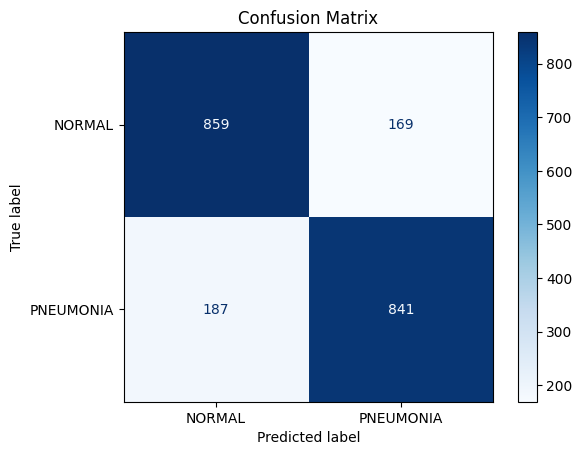

Testing the model...
Test Accuracy: 83.0904, Test Loss: 0.4420, Test Precision: 0.8311, Test Recall: 0.8309, Test F1 Score: 0.8310


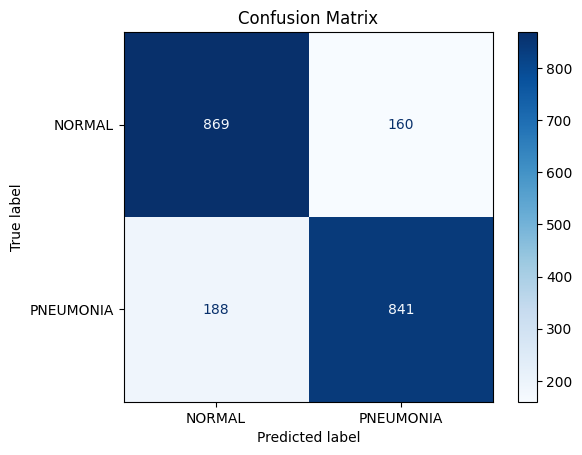

Measuring inference time...
Average Inference Time: 0.016264 seconds/image
System Resources:
CPU Usage: 64.4%
RAM Usage: 24.8%
GPU Memory Usage: 2.79 GB


In [ ]:
# Import the necessary modules
import torch  # PyTorch for deep learning
from torch.utils.data import DataLoader  # For batching and shuffling data
from torchvision import datasets  # For loading image datasets
from transformers import AutoImageProcessor, AutoModelForImageClassification  # HuggingFace transformers for models and preprocessing
from torchvision.transforms import Compose, RandomHorizontalFlip, RandomRotation, ColorJitter  # Data augmentation utilities
from torch.nn import init  # For weight initialisation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # For confusion matrix visualisation
import matplotlib.pyplot as plt  # For plotting graphs and matrices
import time  # For measuring execution time
import psutil  # For monitoring system resources like CPU and RAM usage

# Constants
MODEL_NAME = "google/vit-base-patch16-224-in21k"  # Pretrained ViT model identifier from HuggingFace
BATCH_SIZE = 32  # Number of images in each batch
NUM_CLASSES = 2  # Number of output classes (e.g., NORMAL and PNEUMONIA)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available, otherwise CPU
NUM_EPOCHS = 5  # Number of epochs for training

# Load the processor and model
print("Loading processor and model...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast=True)  # Load the pretrained image processor
vit_model = AutoModelForImageClassification.from_pretrained(  # Load the pretrained ViT model
    MODEL_NAME,  # Model identifier
    num_labels=NUM_CLASSES  # Configure the model for binary classification
).to(DEVICE)  # Move the model to the appropriate device (GPU/CPU)

# Debugging: Output the type of processor being used
print(f"Using processor: {type(processor).__name__}")

# Initialise the classification head explicitly
print("Initialising classification head weights...")
init.xavier_uniform_(vit_model.classifier.weight)  # Use Xavier initialisation for weights
init.zeros_(vit_model.classifier.bias)  # Initialise bias to zero

# Define a preprocessing function with data augmentation for the training dataset wit augmentation
def preprocess_function_train(image):
    augmentations = Compose([  # Compose several transformations into a single pipeline
        RandomHorizontalFlip(p=0.5),  # Apply horizontal flip with 50% probability
        RandomRotation(degrees=10),  # Rotate the image randomly by + or - 10 degrees
        ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)  # Randomly adjust image color properties
    ])
    augmented_image = augmentations(image)  # Apply the defined augmentations
    return processor(augmented_image, return_tensors="pt")["pixel_values"][0]  # Process the augmented image and extract pixel values

# Define a preprocessing function without augmentation for training without augmentation, validation and test datasets
def preprocess_function_val(image):
    return processor(image, return_tensors="pt")["pixel_values"][0]  # Process the image and extract pixel values

# Load datasets using the preprocessing functions
print("Loading datasets...")
train_dataset_aug = datasets.ImageFolder(train_path, transform=preprocess_function_train)  # Augmented training dataset
train_dataset_no_aug = datasets.ImageFolder(train_path, transform=preprocess_function_val)  # Non-augmented training dataset
val_dataset = datasets.ImageFolder(val_path, transform=preprocess_function_val)  # Validation dataset
test_dataset = datasets.ImageFolder(test_path, transform=preprocess_function_val)  # Test dataset

# Create DataLoaders for batching and shuffling
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)  # DataLoader for augmented training data
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True)  # DataLoader for non-augmented training data
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)  # DataLoader for validation data
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # DataLoader for test data

# Define the optimiser and loss function
optimizer = torch.optim.Adam([  # Use Adam optimiser
    {"params": vit_model.vit.parameters(), "lr": 1e-5},  # Pretrained ViT parameters with a lower learning rate
    {"params": vit_model.classifier.parameters(), "lr": 1e-3},  # Classifier head parameters with a higher learning rate
])
criterion = torch.nn.CrossEntropyLoss()  # Cross-entropy loss for classification tasks

# Function to calculate precision, recall, and F1-score
def calculate_metrics(labels, predictions, num_classes):
    tp = torch.zeros(num_classes, device=DEVICE)  # Initialise true positives for each class
    fp = torch.zeros(num_classes, device=DEVICE)  # Initialise false positives for each class
    fn = torch.zeros(num_classes, device=DEVICE)  # Initialise false negatives for each class

    for c in range(num_classes):  # Loop through each class
        tp[c] = ((predictions == c) & (labels == c)).sum().float()  # Count true positives
        fp[c] = ((predictions == c) & (labels != c)).sum().float()  # Count false positives
        fn[c] = ((predictions != c) & (labels == c)).sum().float()  # Count false negatives

    # Calculate precision, recall, and F1-score for the dataset
    precision = (tp / (tp + fp + 1e-10)).mean().item()  # Mean class-wise precision
    recall = (tp / (tp + fn + 1e-10)).mean().item()  # Mean class-wise recall
    f1 = (2 * precision * recall / (precision + recall + 1e-10))  # Calculate F1 score
    return precision, recall, f1  # Return the metrics

# Define the training loop
def train(model, train_loader, criterion, optimizer, num_epochs):
    model.train()  # Set the model to training mode
    start_time = time.time()  # Record the start time for training
    for epoch in range(1, num_epochs + 1):  # Loop through each epoch (starting from 1)
        running_loss = 0.0  # Track the cumulative loss
        correct_predictions = 0  # Track the number of correct predictions
        total_predictions = 0  # Track the total number of predictions

        for i, (inputs, labels) in enumerate(train_loader, start=1):  # Loop through each batch of data
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)  # Move inputs and labels to the appropriate device

            optimizer.zero_grad()  # Reset gradients for the optimiser
            outputs = model(inputs).logits  # Forward pass through the model
            labels = labels.long()  # Ensure labels are of type Long for compatibility
            loss = criterion(outputs, labels)  # Calculate loss

            loss.backward()  # Backward pass to calculate gradients
            optimizer.step()  # Update the model's weights

            running_loss += loss.item()  # Add the batch loss to the running total
            _, predicted = torch.max(outputs, 1)  # Get the predicted class indices
            correct_predictions += (predicted == labels).sum().item()  # Count correct predictions
            total_predictions += labels.size(0)  # Count total predictions

            # Calculate precision, recall, and F1 score for the batch
            precision, recall, f1 = calculate_metrics(labels, predicted, NUM_CLASSES)

            if (i % 100) == 0:  # Print statistics every 100 batches
                batch_accuracy = correct_predictions / total_predictions  # Calculate batch accuracy
                print(f'Epoch [{epoch}/{num_epochs}], Step [{i}/{len(train_loader)}], '
                      f'Train Accuracy: {batch_accuracy:.4f}, Train Loss: {running_loss / 100:.4f}, '
                      f'Train Precision: {precision:.4f}, Train Recall: {recall:.4f}, Train F1 Score: {f1:.4f}')
                running_loss = 0.0  # Reset running loss after printing

    total_time = time.time() - start_time  # Calculate total training time
    print(f"Training completed in {total_time:.2f} seconds.")  # Print total training time


# Validation/Test Evaluation
def evaluate(model, loader, criterion):
    model.eval()  # Set the model to evaluation mode to disable dropout and other training-specific behaviors
    all_labels = []  # List to store all ground-truth labels across batches
    all_predictions = []  # List to store all predictions across batches
    total_loss = 0.0  # Initialise the total loss accumulator

    with torch.no_grad():  # Disable gradient computation to save memory and computation during evaluation
        for inputs, labels in loader:  # Loop through the DataLoader, which provides batches of data
            # Move inputs (images) and labels to the appropriate device (GPU/CPU)
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # Forward pass through the model to get logits (raw class scores)
            outputs = model(inputs).logits

            # Calculate the loss for this batch
            loss = criterion(outputs, labels)
            total_loss += loss.item()  # Accumulate the batch loss into the total loss

            # Get predicted class indices from the model's outputs
            _, predicted = torch.max(outputs, 1)  # Take the class with the highest logit score

            # Append the ground-truth labels and predictions for this batch to the lists
            all_labels.append(labels)
            all_predictions.append(predicted)

    # Concatenate all the labels and predictions into single tensors across all batches
    all_labels = torch.cat(all_labels)  # Concatenate ground-truth labels
    all_predictions = torch.cat(all_predictions)  # Concatenate predicted labels

    # Calculate evaluation metrics: precision, recall, and F1 score
    precision, recall, f1 = calculate_metrics(all_labels, all_predictions, NUM_CLASSES)

    # Compute the average loss across all batches
    avg_loss = total_loss / len(loader)  # Divide total loss by the number of batches

    # Calculate overall accuracy as the percentage of correct predictions
    accuracy = 100 * (all_predictions == all_labels).sum().item() / len(all_labels)

    # Return the computed metrics: accuracy, average loss, precision, recall, and F1 score
    return accuracy, avg_loss, precision, recall, f1



# Confusion Matrix Visualisation
def plot_confusion_matrix(model, loader):
    all_labels = []  # List to store all ground-truth labels across batches
    all_predictions = []  # List to store all predictions across batches

    model.eval()  # Set the model to evaluation mode to disable training-specific behaviors (such as dropout)

    with torch.no_grad():  # Disable gradient computation for evaluation to save memory and computation
        for inputs, labels in loader:  # Loop through the DataLoader to process each batch
            # Move inputs (images) to the appropriate device (GPU/CPU)
            inputs = inputs.to(DEVICE)

            # Forward pass through the model to obtain logits (raw class scores)
            outputs = model(inputs).logits

            # Get the predicted class indices (class with the highest logit score)
            _, predicted = torch.max(outputs, 1)

            # Convert labels and predictions to CPU numpy arrays and extend the lists
            all_labels.extend(labels.cpu().numpy())  # Append ground-truth labels
            all_predictions.extend(predicted.cpu().numpy())  # Append predicted labels

    # Compute the confusion matrix using the ground-truth labels and predicted labels
    cm = confusion_matrix(all_labels, all_predictions, labels=list(range(NUM_CLASSES)))

    # Create a ConfusionMatrixDisplay object for visualisation
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])  # Specify class labels

    # Plot the confusion matrix with a blue colormap
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")  # Add a title to the plot
    plt.show()  # Display the confusion matrix



# Measure Inference Time
def measure_inference_time(model, loader):
    model.eval()  # Set the model to evaluation mode to disable training-specific behaviors like dropout
    start_time = time.time()  # Record the start time for measuring inference time

    with torch.no_grad():  # Disable gradient computation to save memory and improve efficiency during inference
        for inputs, _ in loader:  # Iterate through the DataLoader (input images only, labels are not needed)
            inputs = inputs.to(DEVICE)  # Move the inputs (images) to the appropriate device (GPU/CPU)
            _ = model(inputs).logits  # Perform a forward pass to get logits (predictions); discard the outputs

    end_time = time.time()  # Record the end time after all batches have been processed

    # Calculate average inference time per image
    return (end_time - start_time) / len(loader.dataset)  # Divide total time by the number of images in the dataset


# Resource Monitoring
def print_system_resources():
    # Print the current CPU usage percentage
    print(f"CPU Usage: {psutil.cpu_percent()}%")

    # Print the current RAM usage percentage
    print(f"RAM Usage: {psutil.virtual_memory().percent}%")

    # Check if a GPU is available, and if so, print the GPU memory usage
    if torch.cuda.is_available():
        print(f"GPU Memory Usage: {torch.cuda.memory_allocated(DEVICE) / 1e9:.2f} GB")  # Convert bytes to GB



# Training and Evaluation
print("Starting training without data augmentation...")
# Train the model using the non-augmented training dataset
train(vit_model, train_loader_no_aug, criterion, optimizer, NUM_EPOCHS)

print("Starting training with data augmentation...")
# Train the model using the augmented training dataset
train(vit_model, train_loader_aug, criterion, optimizer, NUM_EPOCHS)

# Validation phase
print("Validating the model...")
# Evaluate the model on the validation dataset and retrieve metrics
val_accuracy, val_loss, val_precision, val_recall, val_f1 = evaluate(vit_model, val_loader, criterion)

# Print the validation metrics
print(f'Validation Accuracy: {val_accuracy:.4f}, Validation Loss: {val_loss:.4f}, '
      f'Validation Precision: {val_precision:.4f}, Validation Recall: {val_recall:.4f}, Validation F1 Score: {val_f1:.4f}')

# Plot the confusion matrix for the validation dataset
plot_confusion_matrix(vit_model, val_loader)

# Testing phase
print("Testing the model...")
# Evaluate the model on the test dataset and retrieve metrics
test_accuracy, test_loss, test_precision, test_recall, test_f1 = evaluate(vit_model, test_loader, criterion)

# Print the test metrics
print(f'Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}, '
      f'Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1 Score: {test_f1:.4f}')

# Plot the confusion matrix for the test dataset
plot_confusion_matrix(vit_model, test_loader)

# Measure inference time
print("Measuring inference time...")
# Measure the average time taken to process a single image during inference
inference_time = measure_inference_time(vit_model, test_loader)

# Print the average inference time per image
print(f"Average Inference Time: {inference_time:.6f} seconds/image")

# Monitor system resource usage
print("System Resources:")
# Print current system resource usage (CPU, RAM, GPU)
print_system_resources()



### **CNN Analysis**

This code runs and fine-tunes a pre-trained CNN model in a similar way to the ViT model, but with this model checking to see if there is a linear layer to ensure the classifier's weights are re-initialised for the binary image classification task, particularly after changing the number of output classes from 1000 to 2, as well as modifying the processor so that it handles image processing tasks specific to the ResNet-50 architecture. The same process is carried out as the ViT, where the model is trained on the training set with and without preprocessing and augmentation, and is then validated using the validation set, and tested on unseen data using the testing set.

The results for the CNN model indicate expected performance when compared to the ViT model, as the final metrics for both the augmented (accuracy of 82%, loss of 38% and precision, recall and F1 score of 74%) and unaugmented training (accuracy of 83%, loss of 36%, precision of 77%, recall of 81% and F1 score of 79%) epochs is lower than that of the ViT model. These observations validate the claim that the ViT model gives improved performance over the CNN model, and the validation and test results here are slightly lower than those for the ViT, as well as the loss here being greater than the ViT, indicating that the CNN makes more misclassifications than the ViT. As a result, this validates the claim that a ViT can give clinicians improved performance over a CNN, as well as traditional machine learning models. Furthermore, the unaugmented training data gives better performance than the augmented training data, which, along with the same findings for the ViT model, validates the claim that we can classify raw x-ray images directly as they are in the dataset, rather than artificially trying to improve how they look to try and improve model performance.

The training time for both the augmented (6508 seconds, just over an hour and a half) and unaugmented (2537 seconds, around 45 minutes) data here is lower than those respectively for the ViT model, which is expected, as the ResNet-50 has a more lightweight architecture than the Vision Transformer (base-sized model), so is able to clasify images quicker, although at the cost of reduced metrics. This is because the CNN relies on convolutional layers that focus on local spatial features, making them more computationally efficient than ViTs, and the ResNet-50 specifically requires fewer parameters and less computational overhead for training. However, the inference time is 0.021 seconds per image for the CNN, which is longer than the ViT. This is because ViTs often employ parallelisation and transformer-based computations, which makes their inference time faster on modern GPUs, especially for small batches. This inference time is also ideal for industry practices, but would typically require higher-end equipment, such as more advanced processing units, to speed up training time and improve performance. Additionally, ResNet-50 consumes only 0.81 GB of GPU memory during inference, which is significantly lower than the 2.79 GB required by ViT, making it more resource-efficient. However, this computational efficiency comes at the cost of slightly lower classification metrics, meaning that while staff time may be saved in terms of computational resources and model deployment, clinicians might need to allocate more time to review misclassifications. Therefore, the claim that classifying raw images can save on staff time is partially valid, contingent on the balance between computational efficiency and diagnostic reliability.

The claim "without any downsides" does not hold true for the CNN as much as it does for the ViT, as the validation (all 80%) and testing (all 82%) metrics metrics are slightly less than those of the ViT model. Furthermore, the validation and test loss (both 39%) for the CNN are lower than those for the ViT, which indicates that more misclassifications occur during validation and testing using the CNN. This is further backed up by the false negatives in the confusion matrices, of which there are 246 for the validation set and 235 for the test set, both of which are higher than for the respective metrics for the ViT model. This is alarming in medical diagnostics, as failing to detect pneumonia can have severe consequences for patient outcomes. Similarly, the false positive rate is not negligible, with 143 normal cases being misclassified as pneumonia, potentially leading to unnecessary further testing or treatment. These issues underscore that while ResNet-50 is computationally efficient and achieves acceptable metrics, it does come with downsides in terms of diagnostic reliability, particularly when benchmarked against the ViT model, which exhibits fewer false negatives. Therefore, this claim is not fully supported by the results.

These observations indicate that the ResNet-50 model gives adequate performance for the binary classification task of detecting pneumonia, validating the claim that raw x-ray images can be classified directly and efficiently. However, its performance metrics are slightly lower than those of the ViT model, indicating that improved performance is achievable by selecting more advanced architectures. The computational efficiency and lower resource usage of ResNet-50 support the claim of saving on staff time but with the trade-off of increased false negatives and slightly reduced reliability. This makes the "without any downsides" claim invalid for ResNet-50, as the diagnostic limitations pose a significant concern for clinical applications. Ultimately, while ResNet-50 is a strong model for resource-limited applications, the choice of model should align with the priorities of the application, balancing diagnostic accuracy, computational efficiency, and time constraints. Despite these setbacks, the observations provide a solid foundation for using this pre-trained CNN on higher-end equipment with more resources, making it somewhat suitable for a real-world task of classifying raw x-ray images.

Loading processor and model...


Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-50 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 2048]) in the checkpoint and torch.Size([2, 2048]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using processor: ConvNextImageProcessor
Initialising classification head weights...
Loading datasets...
Starting training without data augmentation...
Epoch [1/5], Step [100/515], Train Accuracy: 0.7025, Train Loss: 0.5843, Train Precision: 0.7745, Train Recall: 0.7917, Train F1 Score: 0.7830
Epoch [1/5], Step [200/515], Train Accuracy: 0.7306, Train Loss: 0.5032, Train Precision: 0.7750, Train Recall: 0.7672, Train F1 Score: 0.7711
Epoch [1/5], Step [300/515], Train Accuracy: 0.7412, Train Loss: 0.4882, Train Precision: 0.6732, Train Recall: 0.6562, Train F1 Score: 0.6646
Epoch [1/5], Step [400/515], Train Accuracy: 0.7513, Train Loss: 0.4613, Train Precision: 0.8250, Train Recall: 0.8377, Train F1 Score: 0.8313
Epoch [1/5], Step [500/515], Train Accuracy: 0.7563, Train Loss: 0.4582, Train Precision: 0.8500, Train Recall: 0.8333, Train F1 Score: 0.8416
Epoch [2/5], Step [100/515], Train Accuracy: 0.7906, Train Loss: 0.4402, Train Precision: 0.8125, Train Recall: 0.8125, Train F1 Score

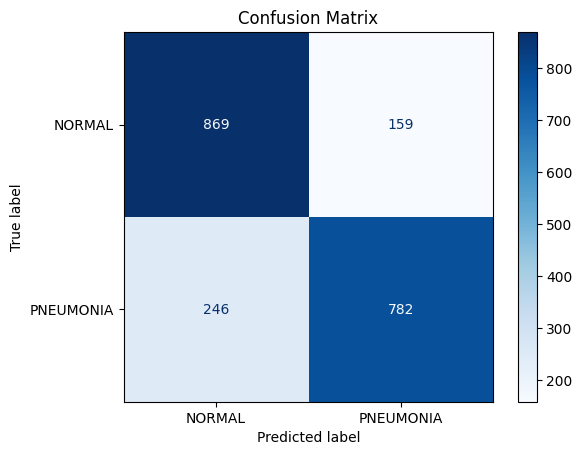

Testing the model...
Test Accuracy: 81.6327, Test Loss: 0.3880, Test Precision: 0.8189, Test Recall: 0.8163, Test F1 Score: 0.8176


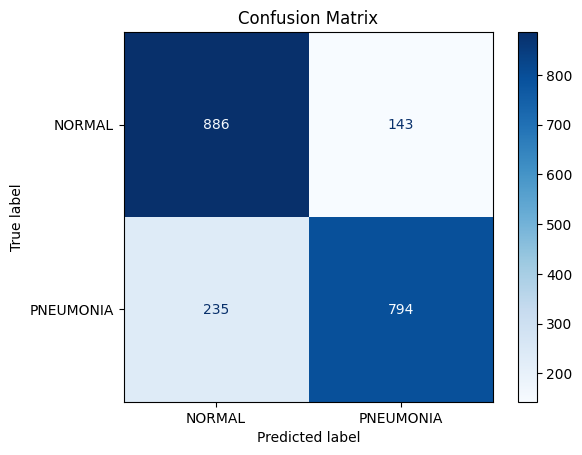

Measuring inference time...
Average Inference Time: 0.021451 seconds/image
System Resources:
CPU Usage: 64.2%
RAM Usage: 25.3%
GPU Memory Usage: 0.81 GB


In [3]:
# Import the necessary modules
import torch  # PyTorch for deep learning
from torch.utils.data import DataLoader  # For batching and shuffling data
from torchvision import datasets  # For loading image datasets
from transformers import AutoImageProcessor, AutoModelForImageClassification  # HuggingFace transformers for models and preprocessing
from torchvision.transforms import Compose, RandomHorizontalFlip, RandomRotation, ColorJitter  # Data augmentation utilities
from torch.nn import init  # For weight initialization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # For confusion matrix visualisation
import matplotlib.pyplot as plt  # For plotting graphs and matrices
import time  # For measuring execution time
import psutil  # For monitoring system resources like CPU and RAM usage

# Constants
MODEL_NAME = "microsoft/resnet-50"  # Pretrained ResNet-50 model identifier from HuggingFace
BATCH_SIZE = 32  # Number of images in each batch
NUM_CLASSES = 2  # Binary classification (NORMAL, PNEUMONIA)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 5  # Training epochs

# Load the processor and model
print("Loading processor and model...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)  # Load the pretrained ResNet-50 image processor
cnn_model = AutoModelForImageClassification.from_pretrained(  # Load the pretrained ResNet-50 model
    MODEL_NAME,  # Model identifier
    num_labels=NUM_CLASSES,  # Configure the model for binary classification
    ignore_mismatched_sizes=True # Ignore size mismatches for the classifier layer
).to(DEVICE)  # Move the model to the appropriate device (GPU/CPU)

# Debugging: Output the type of processor being used
print(f"Using processor: {type(processor).__name__}")

# Initialise the classification head explicitly
print("Initialising classification head weights...")

# Locate the Linear layer in the classifier
if isinstance(cnn_model.classifier, torch.nn.Sequential):  # Check if the classifier is a Sequential container
    for layer in cnn_model.classifier:
        if isinstance(layer, torch.nn.Linear):  # Locate the Linear layer
            init.xavier_uniform_(layer.weight)  # Use Xavier initialisation for weights
            init.zeros_(layer.bias)  # Initialise bias to zero
            break  # Found the Linear layer, exit the loop
else:
    # If the classifier is not a Sequential container, handle it directly
    init.xavier_uniform_(cnn_model.classifier.weight)
    init.zeros_(cnn_model.classifier.bias)


# Define a preprocessing function with data augmentation for the training dataset with augmentation
def preprocess_function_train(image):
    augmentations = Compose([  # Compose several transformations into a single pipeline
        RandomHorizontalFlip(p=0.5),  # Apply horizontal flip with 50% probability
        RandomRotation(degrees=10),  # Rotate the image randomly by + or - 10 degrees
        ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)  # Randomly adjust image color properties
    ])
    augmented_image = augmentations(image)  # Apply the defined augmentations
    return processor(augmented_image, return_tensors="pt")["pixel_values"][0]  # Process the augmented image and extract pixel values

# Define a preprocessing function without augmentation for training without augmentation, validation, and test datasets
def preprocess_function_val(image):
    return processor(image, return_tensors="pt")["pixel_values"][0]  # Process the image and extract pixel values

# Load datasets using the preprocessing functions
print("Loading datasets...")
train_dataset_aug = datasets.ImageFolder(train_path, transform=preprocess_function_train)  # Augmented training dataset
train_dataset_no_aug = datasets.ImageFolder(train_path, transform=preprocess_function_val)  # Non-augmented training dataset
val_dataset = datasets.ImageFolder(val_path, transform=preprocess_function_val)  # Validation dataset
test_dataset = datasets.ImageFolder(test_path, transform=preprocess_function_val)  # Test dataset

# Create DataLoaders for batching and shuffling
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)  # DataLoader for augmented training data
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True)  # DataLoader for non-augmented training data
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)  # DataLoader for validation data
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # DataLoader for test data

# Define the optimizer and loss function
optimizer = torch.optim.Adam([  # Use Adam optimizer
    {"params": cnn_model.resnet.parameters(), "lr": 1e-5},  # Pretrained ResNet parameters with a lower learning rate
    {"params": cnn_model.classifier.parameters(), "lr": 1e-3},  # Classifier head parameters with a higher learning rate
])
criterion = torch.nn.CrossEntropyLoss()  # Cross-entropy loss for classification tasks

# Function to calculate precision, recall, and F1-score
def calculate_metrics(labels, predictions, num_classes):
    tp = torch.zeros(num_classes, device=DEVICE)  # Initialise true positives for each class
    fp = torch.zeros(num_classes, device=DEVICE)  # Initialise false positives for each class
    fn = torch.zeros(num_classes, device=DEVICE)  # Initialise false negatives for each class

    for c in range(num_classes):  # Loop through each class
        tp[c] = ((predictions == c) & (labels == c)).sum().float()  # Count true positives
        fp[c] = ((predictions == c) & (labels != c)).sum().float()  # Count false positives
        fn[c] = ((predictions != c) & (labels == c)).sum().float()  # Count false negatives

    # Calculate precision, recall, and F1-score for the dataset
    precision = (tp / (tp + fp + 1e-10)).mean().item()  # Mean class-wise precision
    recall = (tp / (tp + fn + 1e-10)).mean().item()  # Mean class-wise recall
    f1 = (2 * precision * recall / (precision + recall + 1e-10))  # Calculate F1 score
    return precision, recall, f1  # Return the metrics




# Define the training loop
def train(model, train_loader, criterion, optimizer, num_epochs):
    model.train()  # Set the model to training mode
    start_time = time.time()  # Record the start time for training
    for epoch in range(1, num_epochs + 1):  # Loop through each epoch (starting from 1)
        running_loss = 0.0  # Track the cumulative loss
        correct_predictions = 0  # Track the number of correct predictions
        total_predictions = 0  # Track the total number of predictions

        for i, (inputs, labels) in enumerate(train_loader, start=1):  # Loop through each batch of data
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)  # Move inputs and labels to the appropriate device

            optimizer.zero_grad()  # Reset gradients for the optimiser
            outputs = model(inputs).logits  # Forward pass through the model
            labels = labels.long()  # Ensure labels are of type Long for compatibility
            loss = criterion(outputs, labels)  # Calculate loss

            loss.backward()  # Backward pass to calculate gradients
            optimizer.step()  # Update the model's weights

            running_loss += loss.item()  # Add the batch loss to the running total
            _, predicted = torch.max(outputs, 1)  # Get the predicted class indices
            correct_predictions += (predicted == labels).sum().item()  # Count correct predictions
            total_predictions += labels.size(0)  # Count total predictions

            # Calculate precision, recall, and F1 score for the batch
            precision, recall, f1 = calculate_metrics(labels, predicted, NUM_CLASSES)

            if (i % 100) == 0:  # Print statistics every 100 batches
                batch_accuracy = correct_predictions / total_predictions  # Calculate batch accuracy
                print(f'Epoch [{epoch}/{num_epochs}], Step [{i}/{len(train_loader)}], '
                      f'Train Accuracy: {batch_accuracy:.4f}, Train Loss: {running_loss / 100:.4f}, '
                      f'Train Precision: {precision:.4f}, Train Recall: {recall:.4f}, Train F1 Score: {f1:.4f}')
                running_loss = 0.0  # Reset running loss after printing

    total_time = time.time() - start_time  # Calculate total training time
    print(f"Training completed in {total_time:.2f} seconds.")  # Print total training time


# Validation/Test Evaluation
def evaluate(model, loader, criterion):
    model.eval()  # Set the model to evaluation mode to disable dropout and other training-specific behaviors
    all_labels = []  # List to store all ground-truth labels across batches
    all_predictions = []  # List to store all predictions across batches
    total_loss = 0.0  # Initialise the total loss accumulator

    with torch.no_grad():  # Disable gradient computation to save memory and computation during evaluation
        for inputs, labels in loader:  # Loop through the DataLoader, which provides batches of data
            # Move inputs (images) and labels to the appropriate device (GPU/CPU)
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # Forward pass through the model to get logits (raw class scores)
            outputs = model(inputs).logits

            # Calculate the loss for this batch
            loss = criterion(outputs, labels)
            total_loss += loss.item()  # Accumulate the batch loss into the total loss

            # Get predicted class indices from the model's outputs
            _, predicted = torch.max(outputs, 1)  # Take the class with the highest logit score

            # Append the ground-truth labels and predictions for this batch to the lists
            all_labels.append(labels)
            all_predictions.append(predicted)

    # Concatenate all the labels and predictions into single tensors across all batches
    all_labels = torch.cat(all_labels)  # Concatenate ground-truth labels
    all_predictions = torch.cat(all_predictions)  # Concatenate predicted labels

    # Calculate evaluation metrics: precision, recall, and F1 score
    precision, recall, f1 = calculate_metrics(all_labels, all_predictions, NUM_CLASSES)

    # Compute the average loss across all batches
    avg_loss = total_loss / len(loader)  # Divide total loss by the number of batches

    # Calculate overall accuracy as the percentage of correct predictions
    accuracy = 100 * (all_predictions == all_labels).sum().item() / len(all_labels)

    # Return the computed metrics: accuracy, average loss, precision, recall, and F1 score
    return accuracy, avg_loss, precision, recall, f1



# Confusion Matrix Visualisation
def plot_confusion_matrix(model, loader):
    all_labels = []  # List to store all ground-truth labels across batches
    all_predictions = []  # List to store all predictions across batches

    model.eval()  # Set the model to evaluation mode to disable training-specific behaviors (such as dropout)

    with torch.no_grad():  # Disable gradient computation for evaluation to save memory and computation
        for inputs, labels in loader:  # Loop through the DataLoader to process each batch
            # Move inputs (images) to the appropriate device (GPU/CPU)
            inputs = inputs.to(DEVICE)

            # Forward pass through the model to obtain logits (raw class scores)
            outputs = model(inputs).logits

            # Get the predicted class indices (class with the highest logit score)
            _, predicted = torch.max(outputs, 1)

            # Convert labels and predictions to CPU numpy arrays and extend the lists
            all_labels.extend(labels.cpu().numpy())  # Append ground-truth labels
            all_predictions.extend(predicted.cpu().numpy())  # Append predicted labels

    # Compute the confusion matrix using the ground-truth labels and predicted labels
    cm = confusion_matrix(all_labels, all_predictions, labels=list(range(NUM_CLASSES)))

    # Create a ConfusionMatrixDisplay object for visualisation
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])  # Specify class labels

    # Plot the confusion matrix with a blue colormap
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")  # Add a title to the plot
    plt.show()  # Display the confusion matrix



# Measure Inference Time
def measure_inference_time(model, loader):
    model.eval()  # Set the model to evaluation mode to disable training-specific behaviors like dropout
    start_time = time.time()  # Record the start time for measuring inference time

    with torch.no_grad():  # Disable gradient computation to save memory and improve efficiency during inference
        for inputs, _ in loader:  # Iterate through the DataLoader (input images only, labels are not needed)
            inputs = inputs.to(DEVICE)  # Move the inputs (images) to the appropriate device (GPU/CPU)
            _ = model(inputs).logits  # Perform a forward pass to get logits (predictions); discard the outputs

    end_time = time.time()  # Record the end time after all batches have been processed

    # Calculate average inference time per image
    return (end_time - start_time) / len(loader.dataset)  # Divide total time by the number of images in the dataset


# Resource Monitoring
def print_system_resources():
    # Print the current CPU usage percentage
    print(f"CPU Usage: {psutil.cpu_percent()}%")

    # Print the current RAM usage percentage
    print(f"RAM Usage: {psutil.virtual_memory().percent}%")

    # Check if a GPU is available, and if so, print the GPU memory usage
    if torch.cuda.is_available():
        print(f"GPU Memory Usage: {torch.cuda.memory_allocated(DEVICE) / 1e9:.2f} GB")  # Convert bytes to GB





# Training the model
print("Starting training without data augmentation...")
train(cnn_model, train_loader_no_aug, criterion, optimizer, NUM_EPOCHS)

print("Starting training with data augmentation...")
train(cnn_model, train_loader_aug, criterion, optimizer, NUM_EPOCHS)

# Validation phase
print("Validating the model...")
val_accuracy, val_loss, val_precision, val_recall, val_f1 = evaluate(cnn_model, val_loader, criterion)

print(f'Validation Accuracy: {val_accuracy:.4f}, Validation Loss: {val_loss:.4f}, '
      f'Validation Precision: {val_precision:.4f}, Validation Recall: {val_recall:.4f}, Validation F1 Score: {val_f1:.4f}')
plot_confusion_matrix(cnn_model, val_loader)

# Testing phase
print("Testing the model...")
test_accuracy, test_loss, test_precision, test_recall, test_f1 = evaluate(cnn_model, test_loader, criterion)

print(f'Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}, '
      f'Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1 Score: {test_f1:.4f}')
plot_confusion_matrix(cnn_model, test_loader)

# Measure inference time
print("Measuring inference time...")
inference_time = measure_inference_time(cnn_model, test_loader)

print(f"Average Inference Time: {inference_time:.6f} seconds/image")

# Monitor system resources
print("System Resources:")
print_system_resources()


## **Conclusion of Claim Based on Results**

In conclusion, the hospital should pursue classifying raw x-ray images for pneumonia detection using the ViT model. The findings from the analysis demonstrate that the ViT model consistently performs better than the CNN (ResNet-50) in terms of accuracy, precision, recall, and F1 score. This makes it a more reliable tool for pneumonia detection, ensuring better clinical outcomes for patients as well as staff, ensuring delays, as well as staff intervention, can be kept to a minimum.

The ViT model achieves higher metric values, particularly on raw (unaugmented) images, with final testing results showing an accuracy of 83%, precision of 83%, recall of 83%, and F1 score of 83%. These metrics are better to the CNN model, which achieved a test accuracy of 82%, precision of 82%, recall of 82%, and F1 score of 82%. These metric differences highlights the ViT model's ability to generalise better to unseen data, which is critical in a clinical setting, where misclassifications have serious consequences. This strongly validates the claim "It should be possible to get improved performance". The ViT model also strongly validates the claim that "we can classify raw x-ray images directly", without preprocessing or augmentation, as evidenced by its higher performance on unaugmented data. This reduces the complexity of the data preparation pipeline, saving valuable time and resources for hospital staff. Moreover, the model demonstrates consistent performance across validation and test datasets, confirming its robustness and reducing the risk of overfitting to the training data.

While the CNN model offers faster training times due to its more lightweight architecture, the ViT model compensates for this with a faster inference time of 0.016 seconds per image compared to the CNN's 0.021 seconds per image. In a real-time diagnostic environment, this difference is significant, as it allows for quicker decision-making, which is critical in emergency cases. Although the training time for the ViT model is longer, this does not impact its usages once deployed in the real world, meaning the time savings during inference and reduced preprocessing requirements support this claim in the long term, and this can be further resolved by using higher-end equipment and computing units (than Colab has) to speed up this training time. This partially validates the claim "save on staff time", due to training time, but offset by inference time and preprocessing savings. Furthermore, as these models are pre-trained, they don't require training from scratch, making the process faster and eliminating the need for manual training in the first instance.

In terms of computational resources, the ViT model is resource-intensive, requiring slightly more GPU memory during training. However, this is manageable with modern hardware. The model also exhibits a relatively high number of false negatives, which poses a clinical risk. However, its lower overall misclassification rate compared to the CNN mitigates this downside. Additional optimisation and integration with human oversight, especially in understanding the underlying processes of the model, as well as advocating secure and ethical training and prediction procedures, can further address this issue. While the claim "without any downsides" is partially valid, due to false negatives and greater resource requirements during training, the ViT model provides significant benefits that compensate for these limitations. It remains a robust and practical solution for the hospital's needs.

As a final recommendation, the colleague's claim can be considered valid with some reasonable adjustments, particularly using faster equipment, and the hospital should employ the ViT model for pneumonia detection using raw x-ray images. The model's high metrics, ability to classify raw images directly, faster inference times, and robustness to unseen data make it a valuable tool for enhancing diagnostic accuracy and efficiency. With carefully-considered implementations and resource allocation, this approach can streamline workflows, reduce diagnostic errors, and ultimately improve patient care and staff jobs, or even better, intervention.

# Aiming for higher marks

Broadly speaking, for higher marks you need to: evaluate extra models; evaluate the impact of relevant hyperparameters; evaluate ensembles of relevant models; take steps to improve on the basic holdout recipe; justify those recipe changes in the relevant text cells. See the assignment specification for full details (including the extension exercise for first class marks).

It's always fine to add new code/text cell pairs in order to do each of these things. Don't worry if you duplicate some aspect of another code cell - it's not a problem and the separation can help keep what you're doing clear and avoid breaking earlier code. On the other hand, if you prefer to make improvements directly to pre-existing cells (e.g., modifying the "Model 1 Evaluation" section above so that it evaluates a range of different hyperparameter settings) then that's absolutely fine too. You don't lose credit for earlier grade bands, because their criteria are still met by the improved code. (The only exception is that you could set out to improve a code listing, but end up breaking it - try to avoid making big changes close to the deadline.)

Whichever approach you take to extending your code, make sure you add/update associated text cells as needed, and update the conclusion at the end of your notebook to reflect your findings.

## Top marks

If you work towards the very highest available marks by critically analysing the colleague statement (see the assignment specification for full details), then you are free to add as many code/text cells as you wish. These might be standard code/text cell pairs like the ones above (e.g., producing experimental findings with a relevant dataset) or they might be text cells in isolation (e.g., presenting findings from your research/reading and/or setting out your analysis). A bit of both is likely to be needed for the very top marks. You are also likely to start citing and referencing other materials as part of this work, and so you will have citations within the body of the notebook, and a final "References" text cell at the end (one has been left below as a reminder).

# References

## **Experimental Findings and Articles**

*   Litjens, G., Kooi, T., Bejnordi, B. E., Setio, A. A. A., Ciompi, F., Ghafoorian, M., van der Laak, J. A. W. M., van Ginneken, B. and Sánchez, C. I. (2017) 'A Survey on Deep Learning in Medical Image Analysis', *Medical Image Analysis*, 42(1), pp. 60-88. Available at: https://doi.org/10.1016/j.media.2017.07.005 (Accessed: 2 December 2024).

*   Rajpurkar, P., Irvin, J., Zhu, K., Yang, B., Mehta, H., Duan, T., Ding, D., Bagul, A., Langlotz, C., Shpanskaya, K., Lungren, M. P. and Ng, A. Y. (2017) 'CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning', *arXiv (Cornell University)*, Cornell University, December. Available at: https://doi.org/10.48550/arXiv.1711.05225 (Accessed: 2 December 2024).

*   Esteva, A., Robicquet, A., Ramsundar, B., Kuleshov, V., DePristo, M., Chou, K., Cui, C., Corrado, G., Thrun, S. and Dean, J. (2019) 'A Guide to Deep Learning in Healthcare', *Nature Medicine*, 25(1), pp. 24-29. Available at: https://doi.org/10.1038/s41591-018-0316-z (Accessed: 3 December 2024).

*   Shen, D., Wu, G. and Suk, H.-I. (2017) 'Deep Learning in Medical Image Analysis', *Annual Review of Biomedical Engineering*, 19(1), pp. 221-248. Available at: https://doi.org/10.1146/annurev-bioeng-071516-044442 (Accessed: 4 December 2024).

*   Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J. and Houlsby, N. (2021) 'An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale', *arXiv (Cornell University)*, Cornell University, June. Available at: https://doi.org/10.48550/arXiv.2010.11929 (Accessed: 4 December 2024).

*   Rajpurkar, P., Irvin, J., Ball, R. L., Zhu, K., Yang, B., Mehta, H., Duan, T., Ding, D., Bagul, A., Langlotz, C. P., Patel, B. N., Yeom, K. W., Shpanskaya, K., Blankenberg, F. G., Seekins, J., Amrhein, T. J., Mong, D. A., Halabi, S. S., Zucker, E. J., Ng, A. Y. and Lungren, M. P. (2018) 'Deep learning for chest radiograph diagnosis: A retrospective comparison of the CheXNeXt algorithm to practicing radiologists', Sheikh, A. (ed.) *PLOS Medicine*, 15(11), p. e1002686. Available at: https://doi.org/10.1371/journal.pmed.1002686 (Accessed: 7 December 2024).

*   Irvin, J., Rajpurkar, P., Ko, M., Yu, Y., Ciurea-Ilcus, S., Chute, C., Marklund, H., Haghgoo, B., Ball, R., Shpanskaya, K., Seekins, J., Mong, D. A., Halabi, S. S., Sandberg, J. K., Jones, R., Larson, D. B., Langlotz, C. P., Patel, B. N., Lungren, M. P. and Ng, A. Y. (2019) 'CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison', *Proceedings of the AAAI Conference on Artificial Intelligence*, 33(1), July, pp. 590-597. Available at: https://doi.org/10.1609/aaai.v33i01.3301590 (Accessed: 7 December 2024).

*   Zhou, B., Khosla, A., Lapedriza, A., Oliva, A. and Torralba, A. (2016) 'Learning Deep Features for Discriminative Localization', *2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, June. Available at: https://doi.org/10.1109/CVPR.2016.319 (Accessed: 8 December 2024).

*   Wang, X., Peng, Y., Lu, L., Lu, Z., Bagheri, M. and Summers, R. M. (2017) 'ChestX-Ray8: Hospital-Scale Chest X-Ray Database and Benchmarks on Weakly-Supervised Classification and Localization of Common Thorax Diseases', *2017 IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, July. Available at: https://doi.org/10.1109/CVPR.2017.369 (Accessed: 11 December 2024).

*   Chen, T., Kornblith, S., Norouzi, M. and Hinton, G. (2020) 'A Simple Framework for Contrastive Learning of Visual Representations', *arXiv (Cornell University)*, Cornell University, January. Available at: https://doi.org/10.48550/arXiv.2002.05709 (Accessed: 11 December 2024).

*   Shin, H.-C., Roth, H. R., Gao, M., Lu, L., Xu, Z., Nogues, I., Yao, J., Mollura, D. and Summers, R. M. (2016) 'Deep Convolutional Neural Networks for Computer-Aided Detection: CNN Architectures, Dataset Characteristics and Transfer Learning', *IEEE Transactions on Medical Imaging*, 35(5), pp. 1285-1298. Available at: https://doi.org/10.1109/TMI.2016.2528162 (Accessed: 13 December 2024).

*   Maguolo, G. and Nanni, L. (2021) 'A critic evaluation of methods for COVID-19 automatic detection from X-ray images', *Information Fusion*, 76, December, pp. 1-7. Available at: https://doi.org/10.1016/j.inffus.2021.04.008 (Accessed: 13 December 2024).

*   Strubell, E., Ganesh, A. and McCallum, A. (2019) 'Energy and Policy Considerations for Deep Learning in NLP', *arXiv (Cornell University)*, Cornell University, June. Available at: https://doi.org/10.48550/arXiv.1906.02243 (Accessed: 15 December 2024).

*   Frid-Adar, M., Diamant, I., Klang, E., Amitai, M., Goldberger, J. and Greenspan, H. (2018) 'GAN-based synthetic medical image augmentation for increased CNN performance in liver lesion classification', *Neurocomputing*, 321, pp. 321-331. Available at: https://doi.org/10.1016/j.neucom.2018.09.013 (Accessed: 15 December 2024).

*   Ghassemi, M., Oakden-Rayner, L. and Beam, A. L. (2021) 'The false hope of current approaches to explainable artificial intelligence in health care', *The Lancet Digital Health*, 3(11), pp. e745-e750. Available at: https://doi.org/10.1016/s2589-7500(21)00208-9 (Accessed: 17 December 2024).

*   Holzinger, A., Langs, G., Denk, H., Zatloukal, K. and Müller, H. (2019) 'Causability and explainability of artificial intelligence in medicine', *WIREs Data Mining and Knowledge Discovery*, 9(4). Available at: https://doi.org/10.1002/widm.1312 (Accessed: 18 December 2024).

*   Rieke, N., Hancox, J., Li, W., Milletarì, F., Roth, H. R., Albarqouni, S., Bakas, S., Galtier, M. N., Landman, B. A., Maier-Hein, K., Ourselin, S., Sheller, M., Summers, R. M., Trask, A., Xu, D., Baust, M. and Cardoso, M. J. (2020) 'The future of digital health with federated learning', *npj Digital Medicine*, 3(119), pp. 1-7. Available: https://doi.org/10.1038/s41746-020-00323-1 (Accessed: 21 December 2024).

*   Halevy, A., Norvig, P. and Pereira, F. (2009) 'The Unreasonable Effectiveness of Data', *IEEE Intelligent Systems*, 24(2), pp. 8-12. Available at: https://doi.org/10.1109/MIS.2009.36 (Accessed: 22 December 2024).

*   Kruse, C. S., Goswamy, R., Raval, Y. and Marawi, S. (2016) 'Challenges and Opportunities of Big Data in Health Care: A Systematic Review', *JMIR Medical Informatics*, 4(4). Available at: https://doi.org/10.2196/medinform.5359 (Accessed: 23 December 2024).

*   Government Digital Service (2019) 'Understanding artificial intelligence ethics and safety', *GOV.UK*. Available at: https://www.gov.uk/guidance/understanding-artificial-intelligence-ethics-and-safety (Accessed: 27 December 2024).

*   Kotter, E. and Ranschaert, E. (2020) 'Challenges and solutions for introducing artificial intelligence (AI) in daily clinical workflow', *European Radiology*, 31(1), pp. 5-7. Available at: https://doi.org/10.1007/s00330-020-07148-2 (Accessed: 27 December 2024).

*   Wipro (2023) 'The Future of Medical Imaging: How AI-Enhanced PACS is Revolutionizing Radiology for Improved Patient Outcomes', *Pharmaceutical & Life Sciences*. Available at: https://www.wipro.com/pharmaceutical-and-life-sciences/the-future-of-medical-imaging-how-ai-enhanced-pacs-is-revolutionizing-radiology-for-improved-patient-outcomes/ (Accessed: 29 December 2024).

*   Heaton, J. (2017) 'Ian Goodfellow, Yoshua Bengio, and Aaron Courville: Deep learning', *Genetic Programming and Evolvable Machines*, 19(1-2), pp. 305-307. Available at: http://dx.doi.org/10.1007/s10710-017-9314-z (Accessed: 29 December 2024).

*   Zech, J. R., Badgeley, M. A., Liu, M., Costa, A. B., Titano, J. J. and Oermann, E. K. (2018) 'Variable generalization performance of a deep learning model to detect pneumonia in chest radiographs: A cross-sectional study', Sheikh, A. (ed.) *PLOS Medicine*, 15(11), p. e1002683. Available at: https://doi.org/10.1371/journal.pmed.1002683 (Accessed: 30 December 2024).

## **Datasets**

*   Santoso, K. A. (2024) 'Chest X-Ray for Pneumonia Dataset'. [Online] Available at: https://www.kaggle.com/datasets/vinadsa/chest-x-ray-for-pneumonia-dataset (Accessed: 17 December 2024).

*   National Institutes of Health Chest X-Ray Dataset (2017) 'NIH Chest X-rays'. [Online] Available at: https://www.kaggle.com/datasets/nih-chest-xrays/data (Accessed: 17 December 2024).

*   Radiological Society of North America (2018) 'RSNA Pneumonia Detection Challenge'. [Online] Available at: https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/ (Accessed: 17 December 2024).

*   Mooney, P. (2017) 'Chest X-Ray Images (Pneumonia)'. [Online] Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia (Accessed: 17 December 2024).

## **Pre-Trained Models**

*   microsoft/resnet-50 (2022) *Hugging Face* [Online] Available at: https://huggingface.co/microsoft/resnet-50 (Accessed: 27 December 2024).

*   google/vit-base-patch16-224-in21k (n.d.) *Hugging Face* [Online] Available at: https://huggingface.co/google/vit-base-patch16-224-in21k (Accessed: 3 January 2025).

# Submission

Once you're ready to submit, you need to compress the whole of your 1CWK100 folder as a .zip file (no other compression formats), and upload it to Moodle. There are several ways to do this, but the instructions below offer a simple step-by-step guide:

*    Make sure the output from all your code cells is showing (you can select 'Runtime' -> 'Run all' if you need to)
*    Save your notebook (select 'File' -> 'Save')
*    Find your /1CWK100/ folder via the Google Drive web interface ([https://drive.google.com/](https://https://drive.google.com/))
*    Right-click on the /1CWK100/ folder, and select 'Download'. This will cause the folder to be compressed into a .zip file and then downloaded to your local machine.
*    Upload the resulting .zip file to the 1CWK100 submission point on Moodle.

**We recommend testing these steps, and asking any questions you might have, well before the final deadline.**